In [52]:
import numpy as np
import few
import os
import sys
import pickle

dir_work = '/home/svu/e1498138/emri_search/work/'
os.chdir(dir_work)
sys.path.insert(0, dir_work)

from GWfuncs_noise import GravWaveAnalysis, build_waveform_response
from loglike_pure_noise import LogLike

sys.path.insert(0, "/nfs/home/svu/e1498138/parismc_dev")
import parismc
import cupy as cp

cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")

use_gpu = True
tdi_gen = 1
dt = 5
T = 12/12 #NOTE: changed!
print(f"Using dt={dt}s, T={T}yr, TDI gen={tdi_gen}")

print('Building ResponseWrapper...')
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=True, tdi_gen=tdi_gen)

print('Building GravWaveAnalysis...')
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=use_gpu, tdi_gen=tdi_gen)
# # Source
# m1 = 1e6
# m2 = 1e1
# a = 0.7
# p0 = 9
# e0 = 0.4
# xI0 = 1.0
# dist = 4.5
# qS = np.pi
# phiS = 0.
# qK = 0.
# phiK = 0.
# Phi_phi0 = 0.4
# Phi_theta0 = 0.0
# Phi_r0 = 0.5    

# Mojito light EMRI_G
m1 = 6.72e5
m2 = 9.84e1
a = 0.5
p0 = 15.7117
e0 = 0.7440
xI0 = 1.0
dist = 4.755
qS = 0.5906
phiS = 3.5808
qK = 1.1707
phiK = 3.8495
Phi_phi0 = 3.1940
Phi_theta0 = 3.3780
Phi_r0 = 0.6038

params_star = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
param_true = [np.log10(m1), np.log10(m2), a, p0, e0, np.cos(qS), phiS]

n_vals = np.arange(-1, 6)
ell = 2

print('Initializing LogLike...')
loglike_obj = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=True,
    seed=42,
    verbose=True,
    ell=ell,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')


def log_density(params):
    """
    Coherent (pure) f-statistic (loglike_pure_noise.LogLike), row-by-row.

    Calls LogLike.__call__ once per row instead of the batched
    log_density_batch path.
    """
    params = np.asarray(params)
    B = params.shape[0]
    logl = np.empty(B, dtype=np.float64)
    for b in range(B):
        logm1, logm2, a_i, p0_i, e0_i, cosqS_i, phiS_i = params[b]
        qS_i = np.arccos(cosqS_i)
        theta = [
            10**logm1, 10**logm2, a_i, p0_i, e0_i,
            xI0, dist, qS_i, phiS_i, qK, phiK,
            Phi_phi0, Phi_theta0, Phi_r0,
        ]
        try:
            logl[b] = loglike_obj(theta)
        except Exception:
            logl[b] = -np.inf
    return logl


def prior_transform(u):
    logm1lim = [5.82507, 5.82762]
    logm2lim = [1.99252, 1.99310]
    alim = [0.49334, 0.50078]
    p0lim = [15.70599, 15.75367]
    e0lim = [0.74388, 0.74418]
    cosqSlim = [0.79926, 0.86149]    
    phiSlim = [3.48384, 3.66905]
    t = np.zeros_like(u)
    t[:, 0] = (logm1lim[1] - logm1lim[0]) * u[:, 0] + logm1lim[0]
    t[:, 1] = (logm2lim[1] - logm2lim[0]) * u[:, 1] + logm2lim[0]
    t[:, 2] = (alim[1] - alim[0]) * u[:, 2] + alim[0]
    t[:, 3] = (p0lim[1] - p0lim[0]) * u[:, 3] + p0lim[0]
    t[:, 4] = (e0lim[1] - e0lim[0]) * u[:, 4] + e0lim[0]
    t[:, 5] = (cosqSlim[1] - cosqSlim[0]) * u[:, 5] + cosqSlim[0]
    t[:, 6] = (phiSlim[1] - phiSlim[0]) * u[:, 6] + phiSlim[0]
    return t


def inverse_prior_transform(params):
    logm1lim = [5.82507, 5.82762]
    logm2lim = [1.99252, 1.99310]
    alim = [0.49334, 0.50078]
    p0lim = [15.70599, 15.75367]
    e0lim = [0.74388, 0.74418]
    cosqSlim = [0.79926, 0.86149]    
    phiSlim = [3.48384, 3.66905]
    params = np.asarray(params)
    u = np.zeros_like(params)
    u[:, 0] = (params[:, 0] - logm1lim[0]) / (logm1lim[1] - logm1lim[0])
    u[:, 1] = (params[:, 1] - logm2lim[0]) / (logm2lim[1] - logm2lim[0])
    u[:, 2] = (params[:, 2] - alim[0]) / (alim[1] - alim[0])
    u[:, 3] = (params[:, 3] - p0lim[0]) / (p0lim[1] - p0lim[0])
    u[:, 4] = (params[:, 4] - e0lim[0]) / (e0lim[1] - e0lim[0])
    u[:, 5] = (params[:, 5] - cosqSlim[0]) / (cosqSlim[1] - cosqSlim[0])
    u[:, 6] = (params[:, 6] - phiSlim[0]) / (phiSlim[1] - phiSlim[0])
    return u

Using dt=5s, T=1.0yr, TDI gen=1
Building ResponseWrapper...
Building GravWaveAnalysis...
Initializing LogLike...
[INFO] Added colored noise with seed=42
Delta_T for mode selection: 6311.629952709119 seconds
Selected modes (l,m,n): [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)], [(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]]
Selected modes: [[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)], [(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)], [(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)], [(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)], [(2, 0, 4), (2, 1, 4), (2, 2, 4),

In [53]:
#NOTE:corrected
# qS   = 0.5905743164658463
# phiS = 3.580825804842126
# qK   = 0.9327436243181905
# phiK = 3.6550014190179883

In [54]:
pwd

'/nfs/home/svu/e1498138/emri_search/work'

In [55]:
dir_scratch = '/scratch/e1498138/'
savepath = dir_scratch + 'paper/ext/emri_g/stage2_f_smol/'


In [56]:
sampler = parismc.Sampler.load_state(savepath+'/sampler_state.pkl', log_density_func=log_density, prior_transform=prior_transform)
samples, weights = sampler.get_samples_with_weights(flatten=True)
proc_pt = sampler.searched_points_list
logden_list = sampler.searched_log_densities_list


In [57]:
sampler.now_covariances

[array([[ 1.46574105e-03,  9.28309168e-04,  1.51754396e-03,
         -1.53019328e-03, -1.22003834e-03, -1.38093364e-03,
          4.40818899e-05],
        [ 9.28309168e-04,  2.29792024e-03,  7.81466297e-04,
         -7.47141886e-04, -1.54771384e-03, -1.30267796e-03,
          6.77638469e-03],
        [ 1.51754396e-03,  7.81466297e-04,  1.60141169e-03,
         -1.61152517e-03, -1.17593695e-03, -1.44113962e-03,
         -8.72683680e-04],
        [-1.53019328e-03, -7.47141886e-04, -1.61152517e-03,
          1.63097341e-03,  1.17246631e-03,  1.41196808e-03,
          8.93352318e-04],
        [-1.22003834e-03, -1.54771384e-03, -1.17593695e-03,
          1.17246631e-03,  1.37773930e-03,  1.19332330e-03,
         -3.39732735e-03],
        [-1.38093364e-03, -1.30267796e-03, -1.44113962e-03,
          1.41196808e-03,  1.19332330e-03,  2.62747710e-02,
          1.26248162e-02],
        [ 4.40818899e-05,  6.77638469e-03, -8.72683680e-04,
          8.93352318e-04, -3.39732735e-03,  1.26248162e-02

In [58]:
sampler.config

SamplerConfig(seed=953453411, merge_confidence=0.9, alpha=1000, trail_size=1000, boundary_limiting=True, use_beta=True, integral_num=100000, gamma=500, save_interval=0, exclude_scale_z=inf, enforce_trail_size=False, use_pool=False, n_pool=10, parallel_eval=True, max_batch_size=None, speculative_n_guess=None, density_selfcheck=True, stop_on_merge=False, merge_type='distance', merge_criterion=None, merge_check_interval=1, sameruler_cloud=1, single_cloud=1, handover_size=0, handover_interleave=2, handover_align_gamma=True, handover_select='top', epoch_evidence=False, coverage_density_gate=False, coverage_force_merge_iter=None, cov_jitter=1e-10, keep_dead_processes=True, debug=False)

In [59]:
len(sampler.now_covariances)

9

In [60]:
param_true

[5.827369273053825,
 1.9929950984313416,
 0.5,
 15.7117,
 0.744,
 0.8306067129371271,
 3.5808]

In [61]:
n_proc = 9  # processes 0..9
maxld_pts = []
for j in range(n_proc):
    nj = sampler.element_num_list[j]
    pt = prior_transform(proc_pt[j][:nj][np.argmax(logden_list[j][:nj])].reshape(1, -1))
    maxld_pts.append(pt)
    print(f"maxld_pt{j+1} =", pt)

maxld_pt1, maxld_pt2, maxld_pt3, maxld_pt4, maxld_pt5, \
maxld_pt6, maxld_pt7, maxld_pt8, maxld_pt9 = maxld_pts

maxld_pt1 = [[ 5.82595158  1.99267966  0.49587826 15.73817815  0.74416625  0.82400395
   3.55596108]]
maxld_pt2 = [[ 5.82737303  1.99274249  0.49996209 15.70942366  0.74404283  0.83018677
   3.64346697]]
maxld_pt3 = [[ 5.827001    1.99263838  0.49893721 15.71610288  0.74409248  0.85157097
   3.61306908]]
maxld_pt4 = [[ 5.82683051  1.9930751   0.49697712 15.72546442  0.74398187  0.80755098
   3.52927322]]
maxld_pt5 = [[ 5.82693234  1.99306431  0.49904054 15.72011393  0.74412956  0.86048206
   3.51941716]]
maxld_pt6 = [[ 5.82611031  1.99300071  0.49652963 15.73834038  0.74401147  0.80036278
   3.48629302]]
maxld_pt7 = [[ 5.82586306  1.99309855  0.49496559 15.74601059  0.74391921  0.84304694
   3.59179391]]
maxld_pt8 = [[ 5.82739367  1.99307365  0.4976326  15.71518185  0.74390656  0.81283069
   3.59814561]]
maxld_pt9 = [[ 5.82618268  1.99290506  0.49938496 15.73408894  0.74390361  0.82196702
   3.59040418]]


In [62]:
log_density(maxld_pt1.reshape(1,-1))

rho_tot=101.431, rho_dom_M=24.3209, beta=0.000658222
               group          X_m        rho_m    (X_m-rho_m)^2
[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)]      24.3155      24.3209      2.95263e-05
[(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)]      7.03665      6.24204         0.631406
[(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)]      5.01335      4.93022       0.00691143
[(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)]     -0.58034     0.379316         0.920939
[(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)]      1.16651     0.391778         0.600211
[(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)]     -0.53478     0.351907         0.786214
[(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]     -1.38314     0.295761          2.81869
X_scalar=99.7735, chi_sq=5.7644, f_stat=99.5844
Pure log-likelihood: 99.5844


array([99.58439283])

In [63]:
log_density(np.array(param_true).reshape(1,-1))

rho_tot=100.687, rho_dom_M=24.059, beta=0.000665451
               group          X_m        rho_m    (X_m-rho_m)^2
[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)]      24.7924       24.059         0.537851
[(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)]       7.2595      6.19411          1.13505
[(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)]      5.29168      4.87158         0.176477
[(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)]    -0.363609     0.385405         0.561021
[(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)]      1.09372     0.398495         0.483336
[(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)]    -0.741637     0.358045           1.2093
[(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]     -1.43412     0.301303          3.01168
X_scalar=100.564, chi_sq=7.11472, f_stat=100.326
Pure log-likelihood: 100.326


array([100.32605701])

In [66]:
maxld_pt1[0][2]

0.49587826080969605

In [67]:
qS, phiS

(0.5906, 3.5808)

In [68]:
h_true = gwf.xp.array(waveform_response(
    m1, m2, a, p0, e0,
    xI0, dist,qS, phiS, qK, phiK,
    Phi_phi0, Phi_theta0, Phi_r0,
    T=T, dt=dt,
))

In [69]:
h_pt1 = gwf.xp.array(waveform_response(
    10**maxld_pt1[0][0], 10**maxld_pt1[0][1], maxld_pt1[0][2], maxld_pt1[0][3], maxld_pt1[0][4],
    xI0, dist, maxld_pt1[0][5], maxld_pt1[0][6], qK, phiK,
    Phi_phi0, Phi_theta0, Phi_r0,
    T=T, dt=dt,
))

In [70]:
h_pt1

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [71]:
h_true

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [72]:
gwf.rhostat(h_true), gwf.rhostat(h_pt1)

(array(100.68660759), array(113.69481928))

In [73]:
h_true.shape, h_pt1.shape

((3, 6311629), (3, 6311629))

In [74]:
gwf.inner(gwf.freq_wave(h_true), gwf.freq_wave(h_pt1))


array(3542.81517405)

In [75]:
gwf.inner(gwf.freq_wave(h_true), gwf.freq_wave(h_pt1))/((gwf.rhostat(h_pt1))*(gwf.rhostat(h_true)))

array(0.30948251)

In [76]:
10**5.82595158

669809.9273607938

In [77]:
10**1.99267966 

98.32855568414661

In [78]:
np.arccos(0.82400395)

0.6023543724659218

In [79]:
log_density(maxld_pt1), log_density(maxld_pt2)

rho_tot=101.431, rho_dom_M=24.3209, beta=0.000658222
               group          X_m        rho_m    (X_m-rho_m)^2
[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)]      24.3155      24.3209      2.95263e-05
[(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)]      7.03665      6.24204         0.631406
[(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)]      5.01335      4.93022       0.00691143
[(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)]     -0.58034     0.379316         0.920939
[(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)]      1.16651     0.391778         0.600211
[(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)]     -0.53478     0.351907         0.786214
[(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]     -1.38314     0.295761          2.81869
X_scalar=99.7735, chi_sq=5.7644, f_stat=99.5844
Pure log-likelihood: 99.5844
rho_tot=100.202, rho_dom_M=23.7016, beta=0.000667934
               group          X_m        

(array([99.58439283]), array([72.03751622]))

In [80]:
pt1_alt = [[ 5.82595158, 1.99267966,  0.49587826, 15.73817815,  0.74416625,  np.cos(qS),
   phiS]]

In [81]:
pt1_alt2 = [[ np.log10(m1),np.log10(m2),  a, p0,  e0,  0.8394,
   3.9685]]

In [82]:
log_density(pt1_alt)

rho_tot=100.516, rho_dom_M=23.9697, beta=0.000666763
               group          X_m        rho_m    (X_m-rho_m)^2
[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)]      24.1376      23.9697         0.028162
[(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)]      6.99404      6.15391          0.70582
[(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)]      5.01347      4.86031        0.0234594
[(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)]    -0.511086     0.384622         0.802293
[(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)]       1.4545     0.397843          1.11652
[(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)]    -0.537744      0.35766         0.801749
[(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]     -1.10686     0.301086          1.98232
X_scalar=98.9995, chi_sq=5.46032, f_stat=98.8195
Pure log-likelihood: 98.8195


array([98.81946747])

In [ ]:
compX_alt(pt1_alt)

In [ ]:
log_density(pt1_alt2), compX(pt1_alt2)

In [ ]:
log_density(maxld_pt1), log_density(maxld_pt2), log_density(maxld_pt3), log_density(maxld_pt4), log_density(maxld_pt5), \
log_density(maxld_pt6), log_density(maxld_pt7), log_density(maxld_pt8), log_density(maxld_pt9)

In [ ]:
def compX_alt(pt):
    logm1, logm2, a_i, p0_i, e0_i, cosqS_i, phiS_i = np.asarray(pt).ravel()
    qS_i = np.arccos(cosqS_i)
    h_temp = gwf.xp.array(waveform_response(
        10**logm1, 10**logm2, a_i, p0_i, e0_i,
        xI0, dist, 0.8394, 3.9685, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0,
        T=T, dt=dt,
    ))
    return float(gwf.Xstat(loglike_obj.signal, h_temp))

In [ ]:
def compX(pt):
    logm1, logm2, a_i, p0_i, e0_i, cosqS_i, phiS_i = np.asarray(pt).ravel()
    qS_i = np.arccos(cosqS_i)
    h_temp = gwf.xp.array(waveform_response(
        10**logm1, 10**logm2, a_i, p0_i, e0_i,
        xI0, dist, qS_i, phiS_i, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0,
        T=T, dt=dt,
    ))
    return float(gwf.Xstat(loglike_obj.signal, h_temp))

In [ ]:

X_vals = [compX(pt) for pt in maxld_pts]
for i, x in enumerate(X_vals, 1):
    print(x)

99.79546502707849
72.25143690077509
71.20914630608783
47.864587514871715
42.40032989906758
42.03620655289124
37.757746382880974
34.2812325552286
21.06778007231772


In [ ]:
compX(param_true)

In [ ]:
gwf.rhostat(cp.array(param_true))

In [ ]:
log_density([param_true])

 X_scalar: [100.56383493]
 chi_sq: [7.11471821]
 beta: [0.00066545]
 log-likelihood: [100.32605701]


array([100.32605701])

In [90]:
param_ranges = [(5.82507, 5.82762),
                (1.99252, 1.99310),
                (0.49334, 0.50078),
                (15.70599, 15.75367),
                (0.74388, 0.74418),
                (0.79926, 0.86149),
                (3.48384, 3.66905)
                ]
param_ranges



[(5.82507, 5.82762),
 (1.99252, 1.9931),
 (0.49334, 0.50078),
 (15.70599, 15.75367),
 (0.74388, 0.74418),
 (0.79926, 0.86149),
 (3.48384, 3.66905)]

In [18]:
param_true = [np.log10(m1), np.log10(m2), a, p0, e0,np.cos(qS),phiS]
param_true

[5.827369273053825,
 1.9929950984313416,
 0.5,
 15.7117,
 0.744,
 0.8306067129371271,
 3.5808]

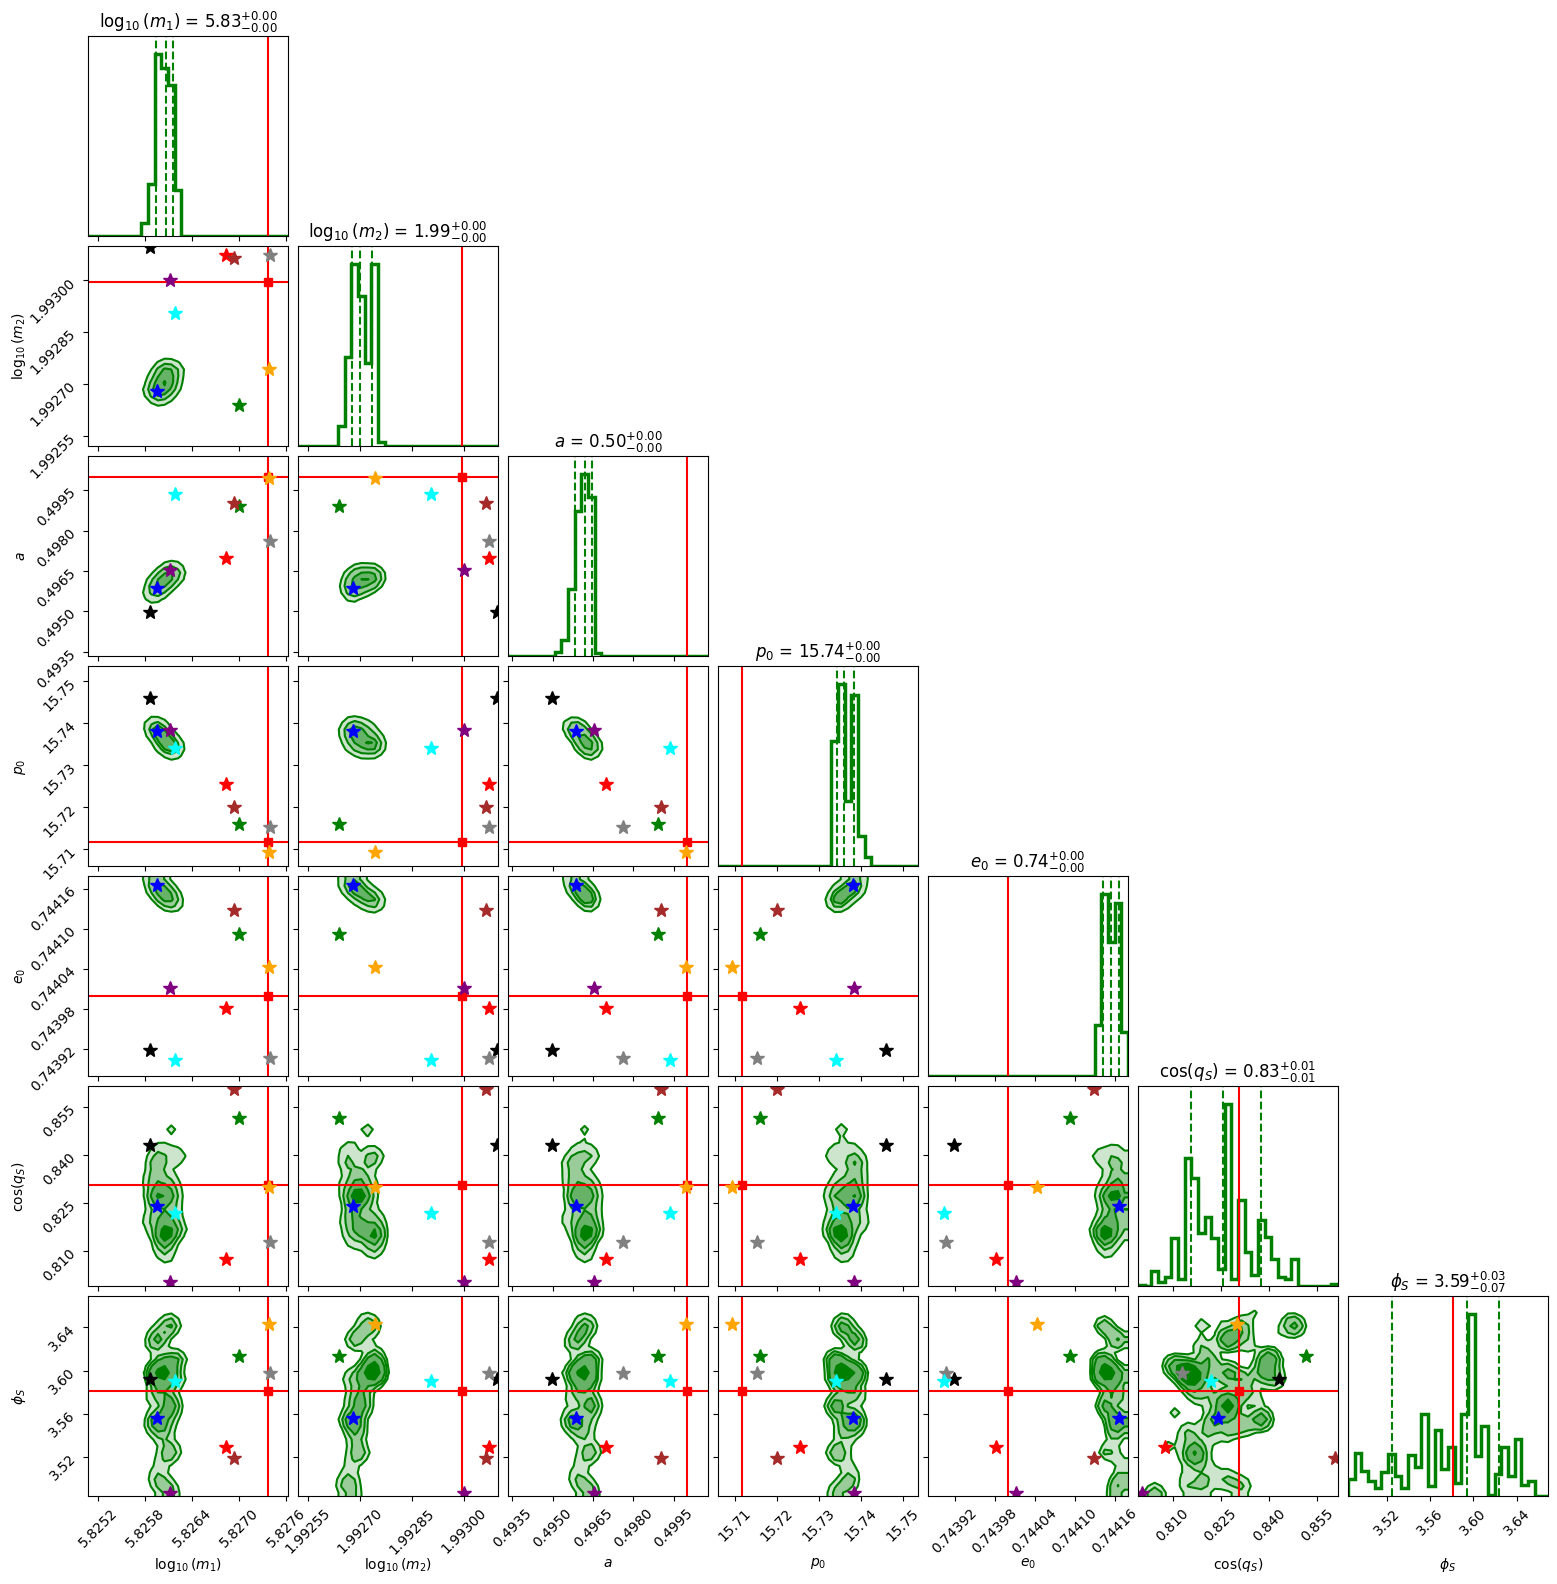

In [19]:
import corner
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$',r'$\cos(q_S)$', r'$\phi_S$']
fig = corner.corner(
    samples,
    weights=weights,
    labels=labels,
    truths=param_true,
    truth_color='red',
    color='green',
    show_titles=True,
    label_kwargs={"fontsize": 10},
    title_kwargs={"fontsize": 12},
    quantiles=[0.16, 0.5, 0.84],
    smooth=True,
    bins=30,
    plot_datapoints=False,
    hist_kwargs={"density": True, 'linewidth': 2.5},
    linewidth=2.5,
    fill_contours=True,
    range = param_ranges
)

corner.overplot_points(fig, maxld_pt1.reshape(1, -1), 
                       color='blue', marker='*', ms=10, 
                       reverse=False)

corner.overplot_points(fig, maxld_pt2.reshape(1, -1), 
                       color='orange', marker='*', ms=10, 
                       reverse=False)

corner.overplot_points(fig, maxld_pt3.reshape(1, -1), 
                       color='green', marker='*', ms=10, 
                       reverse=False)

corner.overplot_points(fig, maxld_pt4.reshape(1, -1), 
                       color='red', marker='*', ms=10, 
                       reverse=False)

corner.overplot_points(fig, maxld_pt5.reshape(1, -1), 
                       color='brown', marker='*', ms=10, 
                       reverse=False)

corner.overplot_points(fig, maxld_pt6.reshape(1, -1), 
                       color='purple', marker='*', ms=10, 
                       reverse=False)

corner.overplot_points(fig, maxld_pt7.reshape(1, -1), 
                       color='black', marker='*', ms=10, 
                       reverse=False)

corner.overplot_points(fig, maxld_pt8.reshape(1, -1), 
                       color='gray', marker='*', ms=10, 
                       reverse=False)

corner.overplot_points(fig, maxld_pt9.reshape(1, -1), 
                       color='cyan', marker='*', ms=10, 
                       reverse=False)



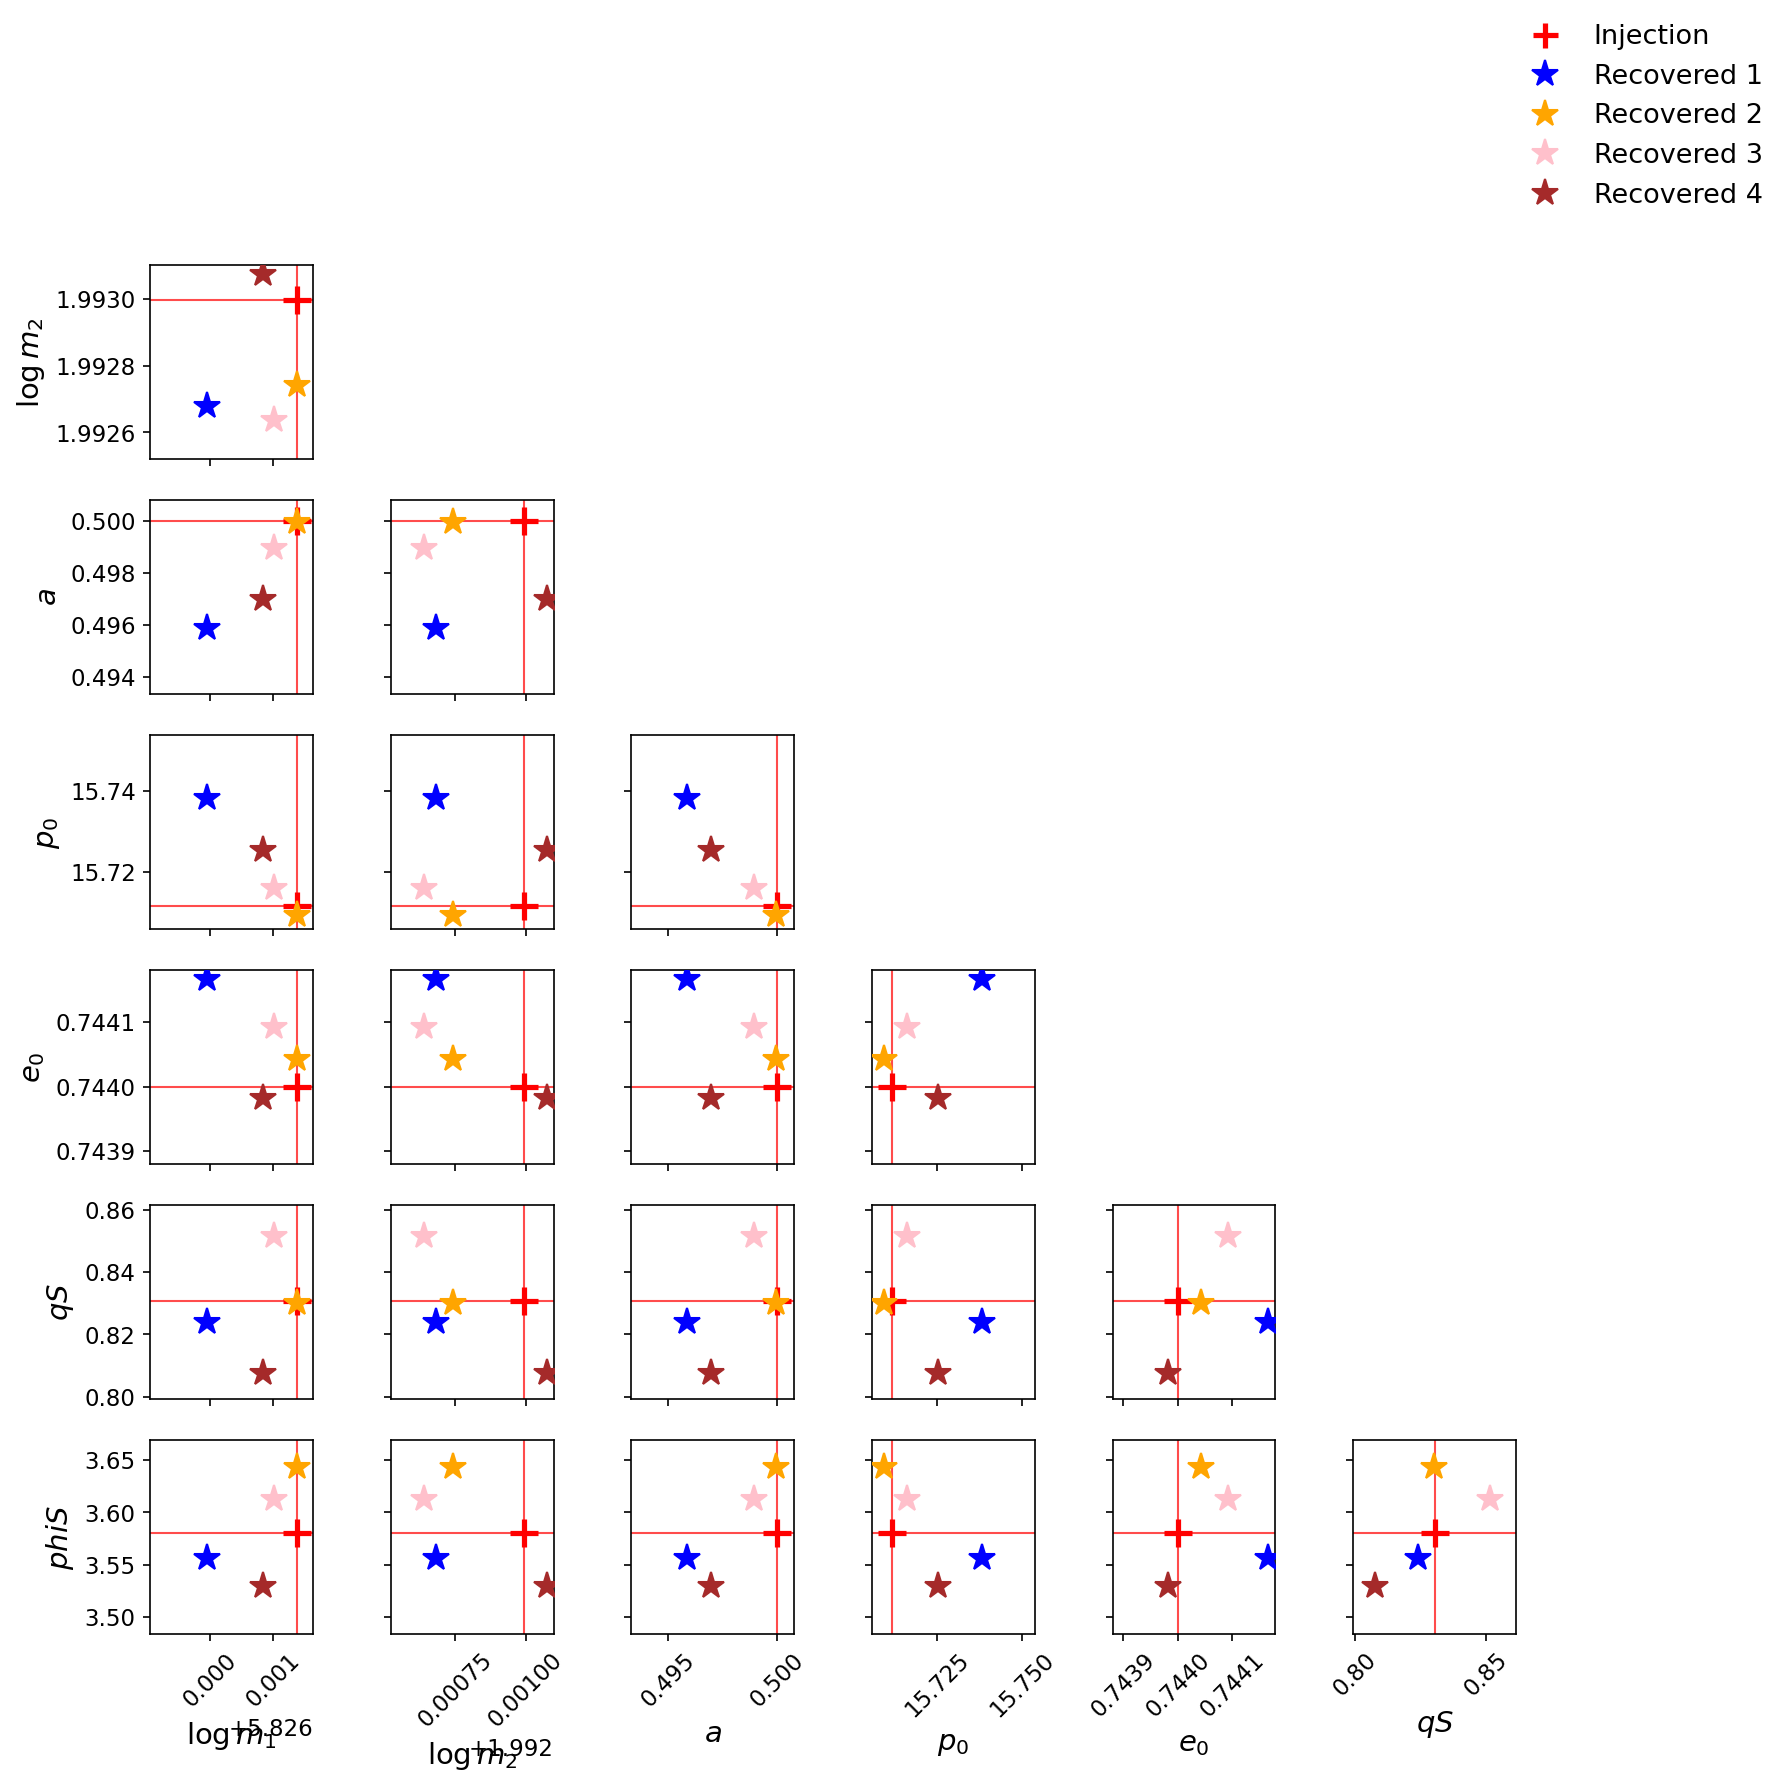

In [20]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    'font.size': 13, 'axes.labelsize': 14,
    'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$', r'$qS$', r'$phiS$']
ndim = len(labels)

param_true = np.asarray(param_true).ravel()
maxld_pt1  = np.asarray(maxld_pt1).ravel()
maxld_pt2  = np.asarray(maxld_pt2).ravel()
maxld_pt3  = np.asarray(maxld_pt3).ravel()
maxld_pt4  = np.asarray(maxld_pt4).ravel()
maxld_pt5  = np.asarray(maxld_pt5).ravel()
maxld_pt6  = np.asarray(maxld_pt6).ravel()
maxld_pt7  = np.asarray(maxld_pt7).ravel()
maxld_pt8  = np.asarray(maxld_pt8).ravel()
maxld_pt9  = np.asarray(maxld_pt9).ravel()

# full prior width per parameter: param_ranges = [(lo, hi), ...]
param_ranges = [tuple(r) for r in param_ranges]

fig, axes = plt.subplots(ndim, ndim, figsize=(12, 12))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        if j >= i:                       # blank diagonal + upper triangle
            ax.set_visible(False)
            continue

        # injection crosshairs + marker
        ax.axvline(param_true[j], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.axhline(param_true[i], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.plot(param_true[j], param_true[i], '+', color='red',
                ms=13, mew=2.5, zorder=3)

        # recovered MAP point
        ax.plot(maxld_pt1[j], maxld_pt1[i], '*', color='blue',
                ms=13, zorder=4)
        # recovered MAP point
        ax.plot(maxld_pt2[j], maxld_pt2[i], '*', color='orange',
                ms=13, zorder=4)
        # # recovered MAP point
        ax.plot(maxld_pt3[j], maxld_pt3[i], '*', color='pink',
                ms=13, zorder=4)

        ax.plot(maxld_pt4[j], maxld_pt4[i], '*', color='brown',
                ms=13, zorder=4)
                
        # full prior width
        ax.set_xlim(*param_ranges[j])
        ax.set_ylim(*param_ranges[i])

        if j == 0:
            ax.set_ylabel(labels[i])
        else:
            ax.set_yticklabels([])
        if i == ndim - 1:
            ax.set_xlabel(labels[j])
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.set_xticklabels([])

handles = [
    Line2D([0], [0], color='red',  marker='+', ls='', ms=12, mew=2.5, label='Injection'),
    Line2D([0], [0], color='blue', marker='*', ls='', ms=13,          label='Recovered 1'),
    Line2D([0], [0], color='orange', marker='*', ls='', ms=13,          label='Recovered 2'),
    Line2D([0], [0], color='pink', marker='*', ls='', ms=13,          label='Recovered 3'),
    Line2D([0], [0], color='brown', marker='*', ls='', ms=13,          label='Recovered 4'),
]
fig.legend(handles=handles, loc='upper right', frameon=False, fontsize=13)
fig.tight_layout()

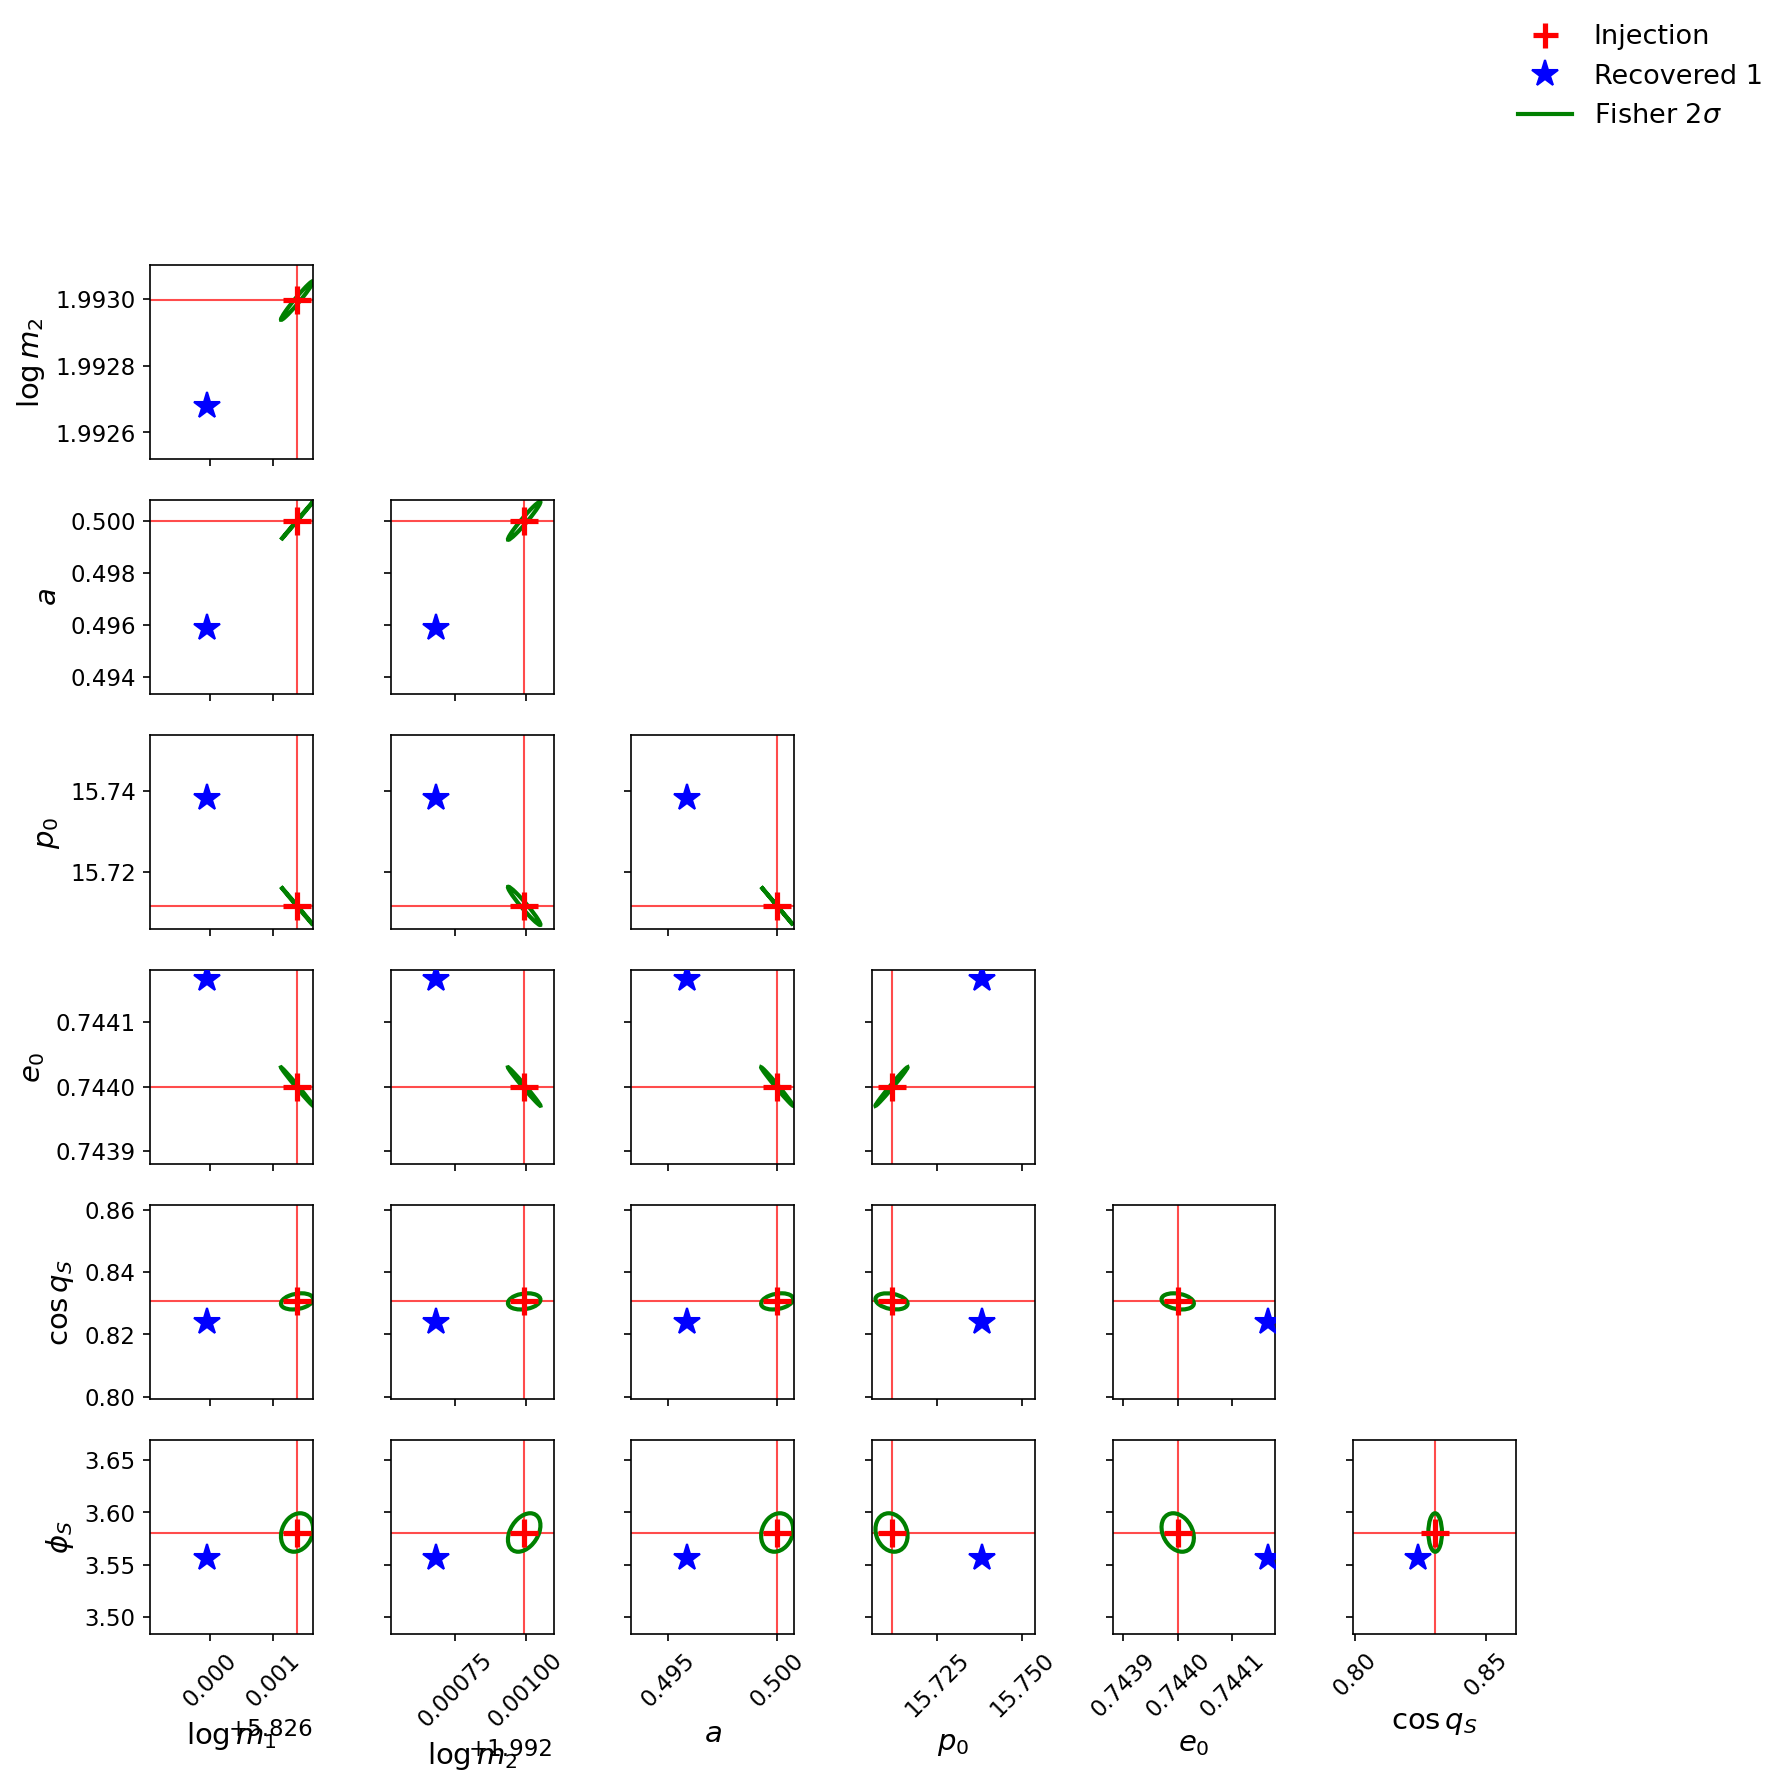

In [24]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D

with open('/home/svu/e1498138/emri_search/work/fisher_mojito_light_g.pkl', 'rb') as f:
    fisher_d = pickle.load(f)

fisher_cov = fisher_d['cov']  # basis: logm1, logm2, a, p0, e0, cosqS, phiS -- same order as param_true/maxld_pt1 here

def draw_cov_ellipse(ax, cx, cy, cov2d, n_sigma=1, **kwargs):
    vals, vecs = np.linalg.eigh(cov2d)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    ell = Ellipse(xy=(cx, cy),
                  width=2 * n_sigma * np.sqrt(vals[0]),
                  height=2 * n_sigma * np.sqrt(vals[1]),
                  angle=angle, **kwargs)
    ax.add_patch(ell)

labels = [r'$\log m_1$', r'$\log m_2$', r'$a$', r'$p_0$', r'$e_0$', r'$\cos q_S$', r'$\phi_S$']
ndim = len(labels)

param_true_arr = np.asarray(param_true).ravel()
maxld_pt1_arr  = np.asarray(maxld_pt1).ravel()
param_ranges = [tuple(r) for r in param_ranges]

fig, axes = plt.subplots(ndim, ndim, figsize=(12, 12))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        if j >= i:
            ax.set_visible(False)
            continue

        # Fisher covariance ellipse (2-sigma), true point as centre
        cov2d = fisher_cov[np.ix_([j, i], [j, i])]
        draw_cov_ellipse(ax, param_true_arr[j], param_true_arr[i], cov2d,
                          n_sigma=2, facecolor='none', edgecolor='green', lw=2, zorder=2)

        # injection crosshairs + marker
        ax.axvline(param_true_arr[j], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.axhline(param_true_arr[i], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.plot(param_true_arr[j], param_true_arr[i], '+', color='red',
                ms=13, mew=2.5, zorder=3)

        # recovered MAP point (proc 1)
        ax.plot(maxld_pt1_arr[j], maxld_pt1_arr[i], '*', color='blue',
                ms=13, zorder=4)

        ax.set_xlim(*param_ranges[j])
        ax.set_ylim(*param_ranges[i])

        if j == 0:
            ax.set_ylabel(labels[i])
        else:
            ax.set_yticklabels([])
        if i == ndim - 1:
            ax.set_xlabel(labels[j])
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.set_xticklabels([])

handles = [
    Line2D([0], [0], color='red',   marker='+', ls='', ms=12, mew=2.5, label='Injection'),
    Line2D([0], [0], color='blue',  marker='*', ls='', ms=13,          label='Recovered 1'),
    Line2D([0], [0], color='green', ls='-', lw=2,                      label='Fisher 2$\sigma$'),
]
fig.legend(handles=handles, loc='upper right', frameon=False, fontsize=13)
fig.tight_layout()


/scratch/e1498138/tmp/ipykernel_1905041/2616778159.py:56: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "^" (-> marker='^'). The keyword argument will take precedence.
  ax.plot(refined_arr[j], refined_arr[i], '^', color='purple',
/scratch/e1498138/tmp/ipykernel_1905041/2616778159.py:56: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "^" (-> marker='^'). The keyword argument will take precedence.
  ax.plot(refined_arr[j], refined_arr[i], '^', color='purple',
/scratch/e1498138/tmp/ipykernel_1905041/2616778159.py:56: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "^" (-> marker='^'). The keyword argument will take precedence.
  ax.plot(refined_arr[j], refined_arr[i], '^', color='purple',
/scratch/e1498138/tmp/ipykernel_1905041/2616778159.py:56: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "^" (->

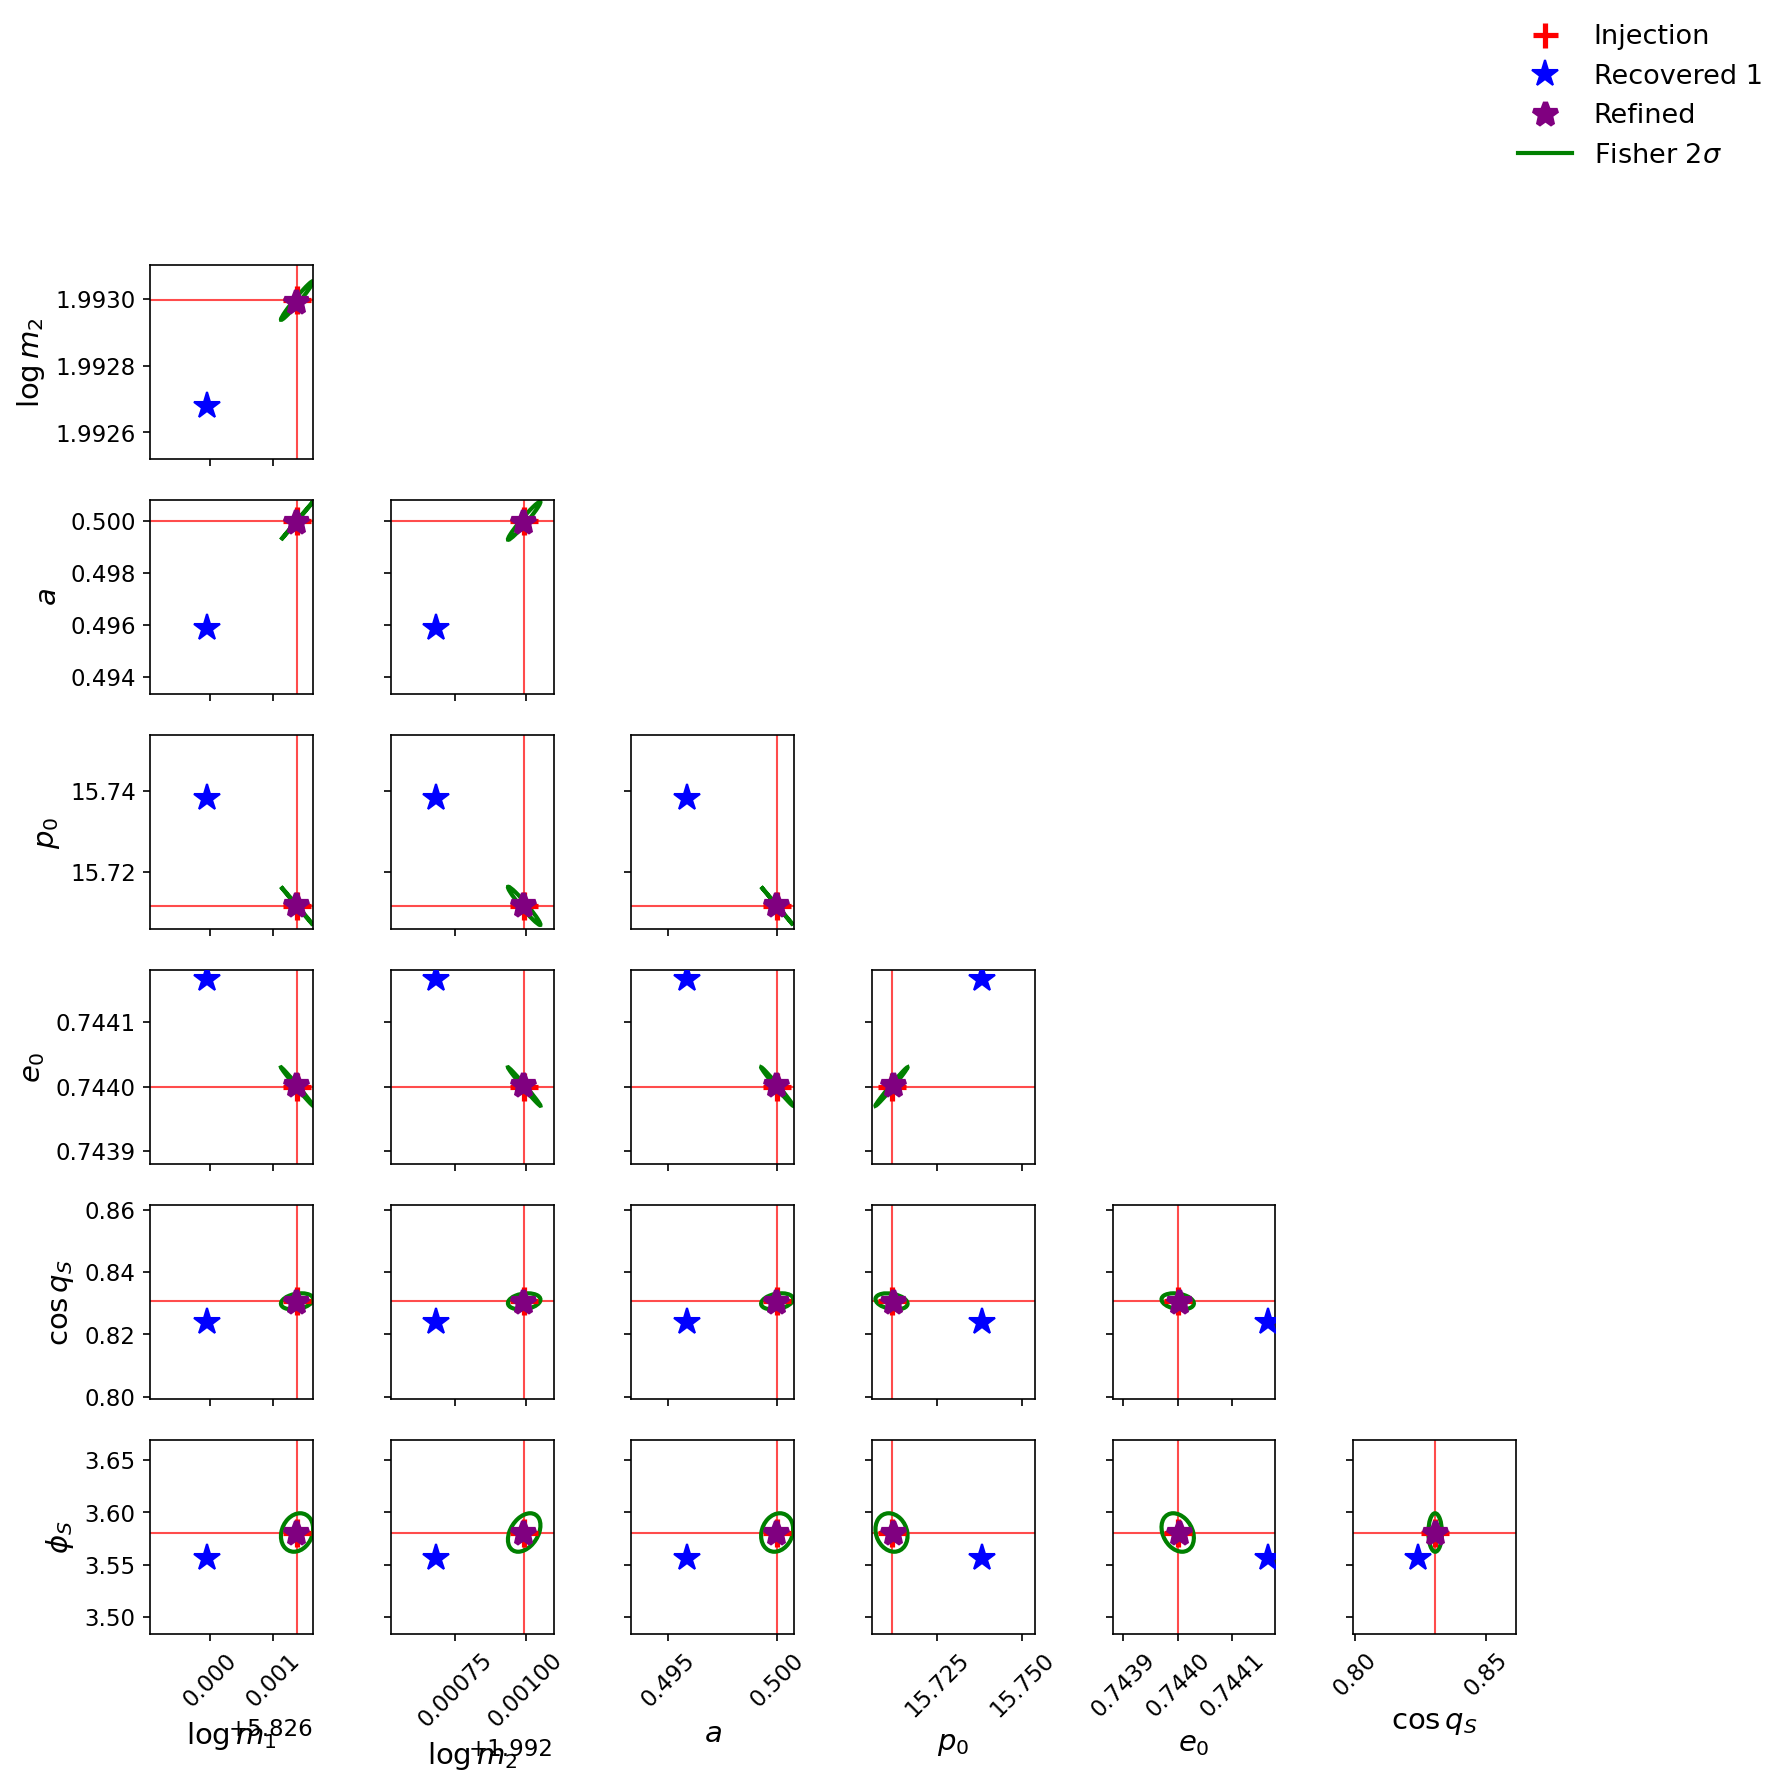

In [28]:
import json
import os

# --- load the refined point, converting to the [logm1, logm2, a, p0, e0, cosqS, phiS] basis ---
RESULTS_PATH = "/nfs/home/svu/e1498138/EMRI_CV_bias/src/EMRI/results_emri_mojito_light.json"

if os.path.exists(RESULTS_PATH):
    with open(RESULTS_PATH) as f:
        cv_result = json.load(f)
    names = cv_result["param_names"]           # [m1, m2, a, p0, e0, qS, phiS, Phi_phi0, Phi_r0]
    refined_full = dict(zip(names, cv_result["refined"]))
else:
    # fallback: hardcoded from the completed PBS run's log
    refined_full = dict(m1=671973.8350437039, m2=98.39917906680147, a=0.499950968955964,
                        p0=15.712016725356543, e0=0.7440019630793491,
                        qS=0.5907509550841762, phiS=3.5807023313943653)

refined_arr = np.array([
    np.log10(refined_full["m1"]),
    np.log10(refined_full["m2"]),
    refined_full["a"],
    refined_full["p0"],
    refined_full["e0"],
    np.cos(refined_full["qS"]),
    refined_full["phiS"],
])

with open('/home/svu/e1498138/emri_search/work/fisher_mojito_light_g.pkl', 'rb') as f:
    fisher_d = pickle.load(f)

fisher_cov = fisher_d['cov']  # basis: logm1, logm2, a, p0, e0, cosqS, phiS -- same order as param_true/maxld_pt1 here

# --- same corner plot as before, with the refined point added ---
fig, axes = plt.subplots(ndim, ndim, figsize=(12, 12))

for i in range(ndim):
    for j in range(ndim):
        ax = axes[i, j]
        if j >= i:
            ax.set_visible(False)
            continue

        cov2d = fisher_cov[np.ix_([j, i], [j, i])]
        draw_cov_ellipse(ax, param_true_arr[j], param_true_arr[i], cov2d,
                          n_sigma=2, facecolor='none', edgecolor='green', lw=2, zorder=2)

        ax.axvline(param_true_arr[j], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.axhline(param_true_arr[i], color='red', lw=1.0, alpha=0.7, zorder=1)
        ax.plot(param_true_arr[j], param_true_arr[i], '+', color='red',
                ms=13, mew=2.5, zorder=3)

        ax.plot(maxld_pt1_arr[j], maxld_pt1_arr[i], '*', color='blue',
                ms=13, zorder=4)

        # NEW: refined (CV-climbed) point
        ax.plot(refined_arr[j], refined_arr[i], '^', color='purple',
                marker='*', ls='', ms=12, mew=2.5,zorder=5)

        ax.set_xlim(*param_ranges[j])
        ax.set_ylim(*param_ranges[i])

        if j == 0:
            ax.set_ylabel(labels[i])
        else:
            ax.set_yticklabels([])
        if i == ndim - 1:
            ax.set_xlabel(labels[j])
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.set_xticklabels([])

handles = [
    Line2D([0], [0], color='red', marker='+', ls='', ms=12, mew=2.5, label='Injection'),
    Line2D([0], [0], color='blue', marker='*', ls='', ms=13, label='Recovered 1'),
    Line2D([0], [0], color='purple', marker='*', ls='', ms=12, mew=2.5, label='Refined'),
    Line2D([0], [0], color='green', ls='-', lw=2, label='Fisher 2$\\sigma$'),
]
fig.legend(handles=handles, loc='upper right', frameon=False, fontsize=13)
fig.tight_layout()

L1 mode-distribution mismatch (true vs maxld_pt1): 0.0099


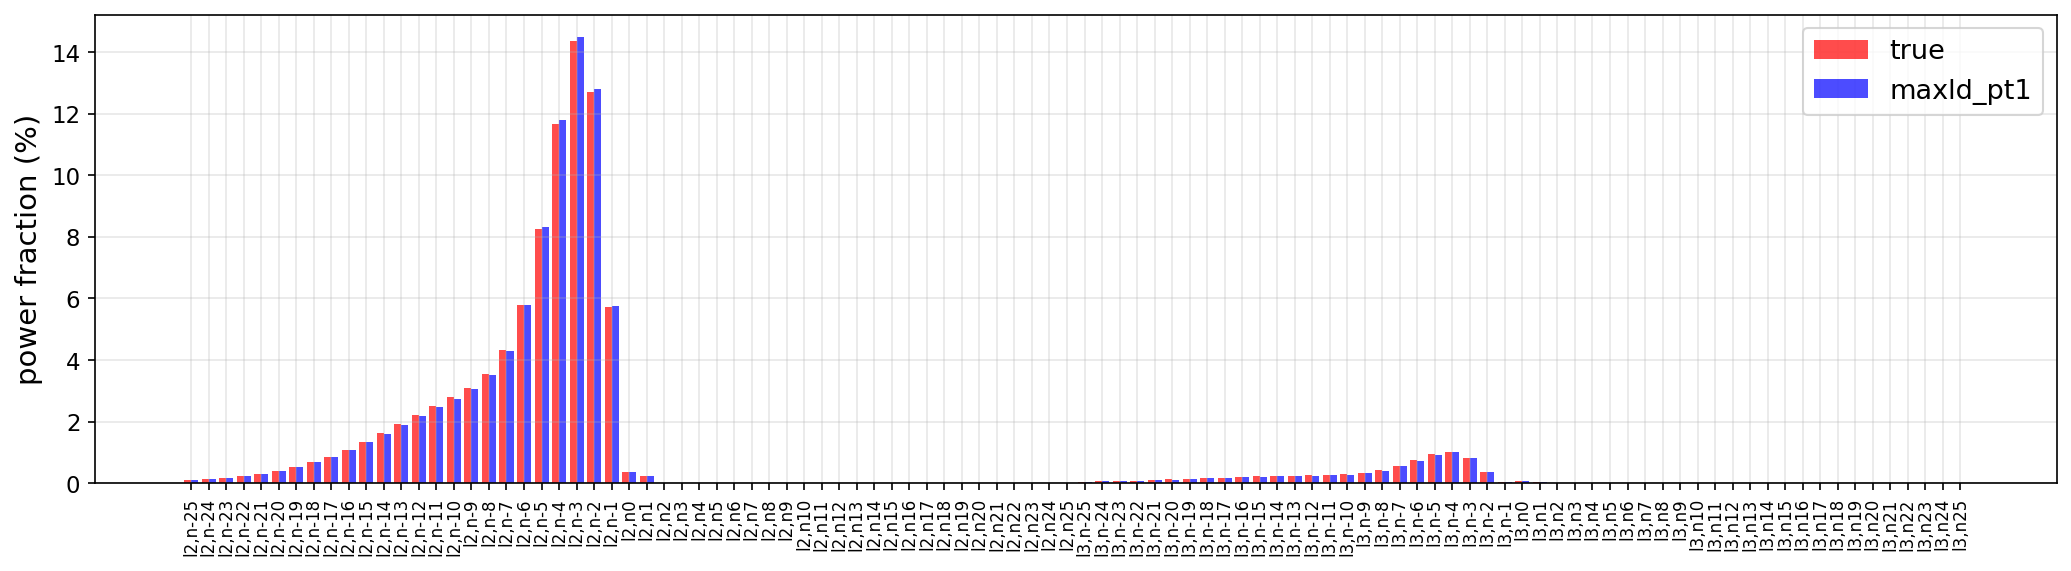

In [20]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

def mode_power_distribution(theta_full, ell_list=(2, 3), n_range=np.arange(-25, 26)):
    """
    theta_full: full 14-param vector [m1, m2, a, p0, e0, xI0, dist, qS, phiS,
                                       qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
    Returns dict: {(l, n): power_frac_pct} for every non-empty (l, n) group,
    normalized against the FULL (all-mode) waveform's rho.
    """
    (m1_, m2_, a_, p0_, e0_, xI0_, dist_, qS_, phiS_, qK_, phiK_,
     Phi_phi0_, Phi_theta0_, Phi_r0_) = theta_full

    h_full = cp.array(waveform_response(
        m1_, m2_, a_, p0_, e0_, xI0_, dist_, qS_, phiS_, qK_, phiK_,
        Phi_phi0_, Phi_theta0_, Phi_r0_, T=T, dt=dt,
    ))
    rho_full = float(gwf.rhostat(h_full))

    amp = loglike_obj.amp
    l_arr = amp.l_arr.get() if hasattr(amp.l_arr, 'get') else np.asarray(amp.l_arr)
    n_arr = amp.n_arr.get() if hasattr(amp.n_arr, 'get') else np.asarray(amp.n_arr)

    dist_out = {}
    for ell in ell_list:
        for n in n_range:
            mask = (l_arr == ell) & (n_arr == n)
            idxs = np.where(mask)[0]
            if len(idxs) == 0:
                continue
            m_arr = amp.m_arr.get() if hasattr(amp.m_arr, 'get') else np.asarray(amp.m_arr)
            group = [(int(l_arr[i]), int(m_arr[i]), int(n)) for i in idxs]

            h_group = cp.array(waveform_response(
                m1_, m2_, a_, p0_, e0_, xI0_, dist_, qS_, phiS_, qK_, phiK_,
                Phi_phi0_, Phi_theta0_, Phi_r0_, T=T, dt=dt,
                mode_selection=group, include_minus_mkn=False,
            ))
            rho_m = float(gwf.rhostat(h_group))
            dist_out[(ell, n)] = 100.0 * rho_m**2 / rho_full**2

    return dist_out


# --- true vs secondary (maxld_pt1) ---
logm1, logm2, a_s, p0_s, e0_s, cosqS_s, phiS_s = maxld_pt1.ravel()
theta_sec_full = [
    10**logm1, 10**logm2, a_s, p0_s, e0_s, xI0, dist,
    np.arccos(cosqS_s), phiS_s, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,
]

dist_true = mode_power_distribution(params_star)
dist_sec  = mode_power_distribution(theta_sec_full)

all_keys = sorted(set(dist_true) | set(dist_sec), key=lambda k: (k[0], k[1]))
labels_keys = [f"l{l},n{n}" for l, n in all_keys]
vals_true = [dist_true.get(k, 0.0) for k in all_keys]
vals_sec  = [dist_sec.get(k, 0.0) for k in all_keys]

x = np.arange(len(all_keys))
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(x - 0.2, vals_true, width=0.4, color='red', alpha=0.7, label='true')
ax.bar(x + 0.2, vals_sec,  width=0.4, color='blue', alpha=0.7, label='maxld_pt1')
ax.set_xticks(x)
ax.set_xticklabels(labels_keys, rotation=90, fontsize=8)
ax.set_ylabel('power fraction (%)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

# --- a scalar "mode-distribution mismatch" score you can use as a veto ---
p_true = np.array(vals_true) / max(sum(vals_true), 1e-30)
p_sec  = np.array(vals_sec)  / max(sum(vals_sec), 1e-30)
l1_mismatch = np.sum(np.abs(p_true - p_sec))
print(f"L1 mode-distribution mismatch (true vs maxld_pt1): {l1_mismatch:.4f}")


In [22]:
def mode_overlap_comparison(theta_a, theta_b, ell_list=(2, 3), n_range=np.arange(-25, 26)):
    """
    Per-(l,n) normalized complex overlap between waveforms at theta_a and theta_b:
        overlap_m = <h_a,m | h_b,m> / (rho_a,m * rho_b,m)
    overlap_m ~ 1  -> mode m looks the same at both points (genuine degeneracy in that harmonic)
    overlap_m << 1 -> mode m differs; power-fraction match was coincidental
    """
    def unpack(theta):
        return theta  # already full 14-param

    (m1_a, m2_a, a_a, p0_a, e0_a, xI0_a, dist_a, qS_a, phiS_a, qK_a, phiK_a,
     Phi_phi0_a, Phi_theta0_a, Phi_r0_a) = unpack(theta_a)
    (m1_b, m2_b, a_b, p0_b, e0_b, xI0_b, dist_b, qS_b, phiS_b, qK_b, phiK_b,
     Phi_phi0_b, Phi_theta0_b, Phi_r0_b) = unpack(theta_b)

    amp = loglike_obj.amp
    l_arr = amp.l_arr.get() if hasattr(amp.l_arr, 'get') else np.asarray(amp.l_arr)
    n_arr = amp.n_arr.get() if hasattr(amp.n_arr, 'get') else np.asarray(amp.n_arr)
    m_arr = amp.m_arr.get() if hasattr(amp.m_arr, 'get') else np.asarray(amp.m_arr)

    out = {}
    for ell in ell_list:
        for n in n_range:
            idxs = np.where((l_arr == ell) & (n_arr == n))[0]
            if len(idxs) == 0:
                continue
            group = [(int(l_arr[i]), int(m_arr[i]), int(n)) for i in idxs]

            h_a = cp.array(waveform_response(
                m1_a, m2_a, a_a, p0_a, e0_a, xI0_a, dist_a, qS_a, phiS_a, qK_a, phiK_a,
                Phi_phi0_a, Phi_theta0_a, Phi_r0_a, T=T, dt=dt,
                mode_selection=group, include_minus_mkn=False,
            ))
            h_b = cp.array(waveform_response(
                m1_b, m2_b, a_b, p0_b, e0_b, xI0_b, dist_b, qS_b, phiS_b, qK_b, phiK_b,
                Phi_phi0_b, Phi_theta0_b, Phi_r0_b, T=T, dt=dt,
                mode_selection=group, include_minus_mkn=False,
            ))
            fa, fb = gwf.freq_wave(h_a), gwf.freq_wave(h_b)
            rho_a, rho_b = float(gwf.rhostat(h_a)), float(gwf.rhostat(h_b))
            if rho_a == 0 or rho_b == 0:
                continue
            ov = float(gwf.inner(fa, fb, return_complex=False)) / (rho_a * rho_b)
            out[(ell, n)] = ov

    return out


overlaps = mode_overlap_comparison(params_star, theta_sec_full)
for k, v in sorted(overlaps.items(), key=lambda kv: -dist_true.get(kv[0], 0)):
    if dist_true.get(k, 0) > 0.5:  # only show modes carrying non-trivial power
        print(f"l={k[0]:2d} n={k[1]:3d}  power%={dist_true.get(k,0):6.2f}  overlap={v:.4f}")

l= 2 n= -3  power%= 14.36  overlap=0.9949
l= 2 n= -2  power%= 12.70  overlap=0.9953
l= 2 n= -4  power%= 11.68  overlap=0.9938
l= 2 n= -5  power%=  8.27  overlap=0.9932
l= 2 n= -6  power%=  5.78  overlap=0.9936
l= 2 n= -1  power%=  5.71  overlap=0.9928
l= 2 n= -7  power%=  4.33  overlap=0.9941
l= 2 n= -8  power%=  3.55  overlap=0.9940
l= 2 n= -9  power%=  3.10  overlap=0.9934
l= 2 n=-10  power%=  2.78  overlap=0.9924
l= 2 n=-11  power%=  2.50  overlap=0.9914
l= 2 n=-12  power%=  2.21  overlap=0.9903
l= 2 n=-13  power%=  1.92  overlap=0.9893
l= 2 n=-14  power%=  1.62  overlap=0.9884
l= 2 n=-15  power%=  1.34  overlap=0.9875
l= 2 n=-16  power%=  1.09  overlap=0.9866
l= 3 n= -4  power%=  1.01  overlap=0.9879
l= 3 n= -5  power%=  0.93  overlap=0.9847
l= 2 n=-17  power%=  0.87  overlap=0.9857
l= 3 n= -3  power%=  0.82  overlap=0.9913
l= 3 n= -6  power%=  0.74  overlap=0.9826
l= 2 n=-18  power%=  0.68  overlap=0.9848
l= 3 n= -7  power%=  0.55  overlap=0.9830
l= 2 n=-19  power%=  0.52  overlap

In [23]:
vals, vecs = np.linalg.eigh(fisher_cov)   # ascending eigenvalues -> vecs[:, -1] is the most unconstrained direction
top_dir = vecs[:, -1]
top_dir = top_dir / np.linalg.norm(top_dir)

delta = maxld_pt1_arr - param_true_arr
delta_hat = delta / np.linalg.norm(delta)

alignment = np.abs(np.dot(delta_hat, top_dir))
print(f"|cos angle| between (maxld_pt1 - truth) and Fisher's softest eigendirection: {alignment:.4f}")

# how much of delta's Mahalanobis "budget" sits along each eigenmode
proj = vecs.T @ delta
for k in range(len(vals)):
    print(f"eigval={vals[k]:.4g}  proj={proj[k]:+.4g}  proj^2/eigval={proj[k]**2/vals[k]:.3f}")

|cos angle| between (maxld_pt1 - truth) and Fisher's softest eigendirection: 0.7013
eigval=1.218e-17  proj=+5.737e-07  proj^2/eigval=27027.495
eigval=1.784e-15  proj=+4.382e-07  proj^2/eigval=107.642
eigval=2.773e-12  proj=+1.859e-06  proj^2/eigval=1.246
eigval=1.131e-11  proj=+5.074e-06  proj^2/eigval=2.277
eigval=1.491e-06  proj=+0.001001  proj^2/eigval=0.672
eigval=5.702e-06  proj=+0.02647  proj^2/eigval=122.882
eigval=8.477e-05  proj=+0.02606  proj^2/eigval=8.012


# connection plot to proc 1

In [83]:
proc1_maxld_pt = maxld_pt1.copy().reshape(1, -1)
proc1_maxld_pt

array([[ 5.82595158,  1.99267966,  0.49587826, 15.73817815,  0.74416625,
         0.82400395,  3.55596108]])

In [84]:
# connect two highest logden pts

proc1_maxld_pt_1d = proc1_maxld_pt[0] 
true_pt = np.array(param_true)

# NOTE: connecting only till the true/target pt 
n_points = 50
t_values = np.linspace(0, 1, n_points)  # extend beyond each endpoint
line_points_proc1 = proc1_maxld_pt_1d[:, np.newaxis] + t_values * (true_pt - proc1_maxld_pt_1d)[:, np.newaxis]


In [85]:
logden_theory_proc1 = []
logden_theory_proc1.append(log_density(np.array(line_points_proc1).T))


rho_tot=101.431, rho_dom_M=24.3209, beta=0.000658222
               group          X_m        rho_m    (X_m-rho_m)^2
[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)]      24.3155      24.3209      2.95263e-05
[(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)]      7.03665      6.24204         0.631406
[(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)]      5.01335      4.93022       0.00691143
[(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)]     -0.58034     0.379316         0.920939
[(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)]      1.16651     0.391778         0.600211
[(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)]     -0.53478     0.351907         0.786214
[(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]     -1.38314     0.295761          2.81869
X_scalar=99.7735, chi_sq=5.7644, f_stat=99.5844
Pure log-likelihood: 99.5844
rho_tot=101.416, rho_dom_M=24.3158, beta=0.00065837
               group          X_m        r

In [86]:
logden_theory_proc1 = np.array(logden_theory_proc1).flatten()


In [87]:
logden_theory_proc1

array([ 99.58439283,  99.5115197 ,  99.35154551,  99.11683916,
        98.81834918,  98.46726917,  98.07740669,  97.65403576,
        97.20814033,  96.74869087,  96.28326289,  95.81984947,
        95.36511916,  94.92402104,  94.50607219,  94.11239024,
        93.74916079,  93.42067075,  93.12999396,  92.88006771,
        92.67378262,  92.51345378,  92.40085086,  92.33664153,
        92.32141787,  92.3533401 ,  92.43989553,  92.57313648,
        92.75383788,  92.98085756,  93.2521431 ,  93.56549463,
        93.91759763,  94.30492016,  94.72349673,  95.16945361,
        95.63698234,  96.11920094,  96.61402135,  97.11097256,
        97.60272124,  98.08405556,  98.5435715 ,  98.97297113,
        99.36253401,  99.70178963,  99.97946603, 100.18424579,
       100.30395438, 100.32605701])

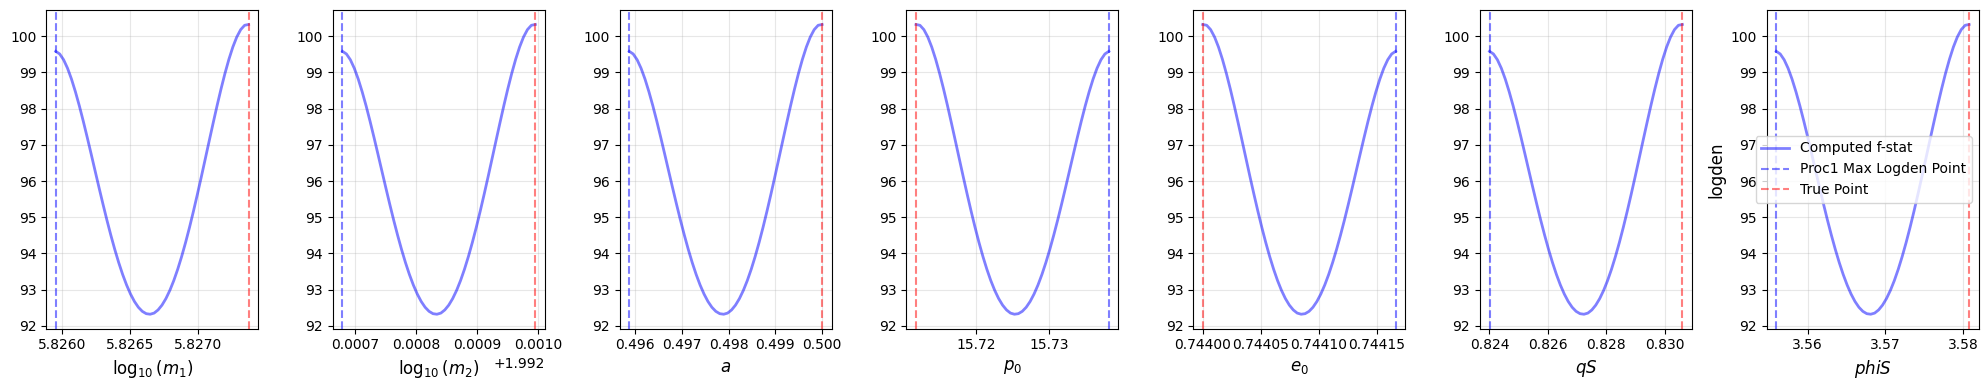

In [88]:
import matplotlib.pyplot as plt
fig_1d, axs_1d = plt.subplots(1, 7, figsize=(20, 4))
labels = [r'$\log_{10}(m_1)$', r'$\log_{10}(m_2)$', r'$a$', r'$p_0$', r'$e_0$', r'$qS$', r'$phiS$']
plt.ylabel('logden', fontsize=12)
for dim in range(7):
    ax = axs_1d[dim]

    # Plot theoretical log-density
    ax.plot(line_points_proc1[dim], logden_theory_proc1, '-', 
            color='blue', alpha=0.5, linewidth=2, label='Computed f-stat')


    # Mark the max likelihood points
    ax.axvline(proc1_maxld_pt_1d[dim], color='blue', linestyle='--', 
               alpha=0.5, label=f'Proc1 Max Logden Point')
    ax.axvline(param_true[dim], color='red', linestyle='--', 
               alpha=0.5, label='True Point')
    
    ax.set_xlabel(labels[dim], fontsize=12)
    # ax.set_ylabel('logden', fontsize=12)
    ax.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()


In [91]:

prior_lo = np.array([r[0] for r in param_ranges])
prior_hi = np.array([r[1] for r in param_ranges])

start = proc1_maxld_pt_1d
direction = true_pt - proc1_maxld_pt_1d
#iterate thru each dim
t_lows, t_highs = [], []
for i in range(len(start)):
    if direction[i] > 0:
        t_lows.append((prior_lo[i] - start[i]) / direction[i])
        t_highs.append((prior_hi[i] - start[i]) / direction[i])
    elif direction[i] < 0:
        t_lows.append((prior_hi[i] - start[i]) / direction[i])
        t_highs.append((prior_lo[i] - start[i]) / direction[i])
    else:
        t_lows.append(-np.inf)
        t_highs.append(np.inf)

t_min = max(t_lows)   # most restrictive lower bound
t_max = min(t_highs)  # most restrictive upper bound

n_points = 50
t_values = np.linspace(t_min, t_max, n_points)
line_points_proc1 = start[:, np.newaxis] + t_values * direction[:, np.newaxis]


In [92]:
i = 0  # logm1
if direction[i] > 0:
    t_lo_logm1 = (prior_lo[i] - start[i]) / direction[i]
    t_hi_logm1 = (prior_hi[i] - start[i]) / direction[i]
else:
    t_lo_logm1 = (prior_hi[i] - start[i]) / direction[i]
    t_hi_logm1 = (prior_lo[i] - start[i]) / direction[i]

n_points = 200
t_values_logm1 = np.linspace(t_lo_logm1, t_hi_logm1, n_points)

# Compute t-values for the required points and insert them
t_true      = (true_pt[i]      - start[i]) / direction[i]
secondary_point = proc1_maxld_pt_1d.copy()

t_secondary = (secondary_point[i] - start[i]) / direction[i]

t_values_logm1 = np.sort(np.concatenate([t_values_logm1, [t_true, t_secondary]]))

line_points_logm1 = start[:, np.newaxis] + t_values_logm1 * direction[:, np.newaxis]


In [93]:
logden_tm = log_density(line_points_logm1.T)


rho_tot=101.968, rho_dom_M=24.4745, beta=0.000652673
               group          X_m        rho_m    (X_m-rho_m)^2
[(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)]      6.58821      24.4745           319.92
[(2, 0, 0), (2, 1, 0), (2, 2, 0), (2, -1, 0), (2, -2, 0)]      3.09839       6.2695          10.0559
[(2, 0, 1), (2, 1, 1), (2, 2, 1), (2, -1, 1), (2, -2, 1)]      3.36357      4.96447          2.56286
[(2, 0, 2), (2, 1, 2), (2, 2, 2), (2, -1, 2), (2, -2, 2)]    -0.348022     0.376953         0.525589
[(2, 0, 3), (2, 1, 3), (2, 2, 3), (2, -1, 3), (2, -2, 3)]      1.31859      0.38891          0.86431
[(2, 0, 4), (2, 1, 4), (2, 2, 4), (2, -1, 4), (2, -2, 4)]    -0.588939      0.34929         0.880274
[(2, 0, 5), (2, 1, 5), (2, 2, 5), (2, -1, 5), (2, -2, 5)]      1.30041     0.293376          1.01411
X_scalar=16.7055, chi_sq=335.823, f_stat=14.9715
Pure log-likelihood: 14.9715
rho_tot=101.957, rho_dom_M=24.4723, beta=0.000652797
               group          X_m       

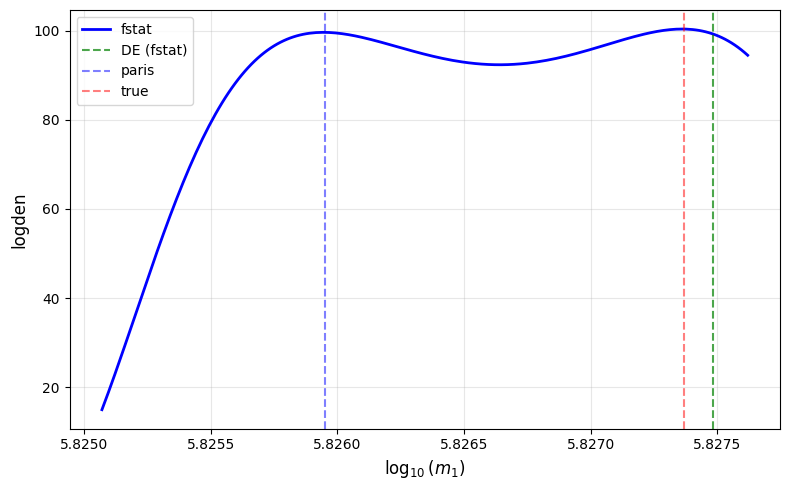

In [95]:
fig, ax = plt.subplots(figsize=(8, 5))

# DE of fstat
GLOBAL_MAP = np.array([5.82748228, 1.99301775, 0.50033221, 15.70956338, 0.74398734, 0.82990829, 3.57624196])



ax.plot(line_points_logm1[0], logden_tm, '-', color='blue', linewidth=2, label='fstat')
# ax.plot(line_points_logm1[0], logden_pure, '-', color='red', linewidth=2, label='f-stat (3mth) pure')
ax.axvline(GLOBAL_MAP[0], color='green', linestyle='--', alpha=0.7, label='DE (fstat)')

ax.axvline(proc1_maxld_pt_1d[0], color='blue', linestyle='--', alpha=0.5, label='paris')
ax.axvline(param_true[0],        color='red',  linestyle='--', alpha=0.5, label='true')
ax.set_xlabel(r'$\log_{10}(m_1)$', fontsize=12)
ax.set_ylabel('logden', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

# alternate mode basis

In [34]:
n_vals = np.arange(-20,21)
loglike_obj_alt = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=False,
    seed=42,
    verbose=True,
    ell=3,
    n_vals=n_vals,
    M_mode=None,
)
print('LogLike initialized.')

def log_density_alt(params):

    params = np.asarray(params)
    out = np.full(params.shape[0], -np.inf)
    for i in range(params.shape[0]):
        logm1, logm2, a_i, p0_i, e0_i, cosqS_i, phiS_i = params[i]
        try:
            qS_i = np.arccos(cosqS_i)
            theta = [
                10**logm1, 10**logm2, a_i, p0_i, e0_i,
                xI0, dist, qS_i, phiS_i, qK, phiK,
                Phi_phi0, Phi_theta0, Phi_r0,
            ]
            out[i] = float(loglike_obj_alt(theta))
        except Exception as e:
            print(e)
    return out

Delta_T for mode selection: 6311.629952709119 seconds
Selected modes (l,m,n): [[(3, 0, -20), (3, 1, -20), (3, 2, -20), (3, 3, -20), (3, -1, -20), (3, -2, -20), (3, -3, -20)], [(3, 0, -19), (3, 1, -19), (3, 2, -19), (3, 3, -19), (3, -1, -19), (3, -2, -19), (3, -3, -19)], [(3, 0, -18), (3, 1, -18), (3, 2, -18), (3, 3, -18), (3, -1, -18), (3, -2, -18), (3, -3, -18)], [(3, 0, -17), (3, 1, -17), (3, 2, -17), (3, 3, -17), (3, -1, -17), (3, -2, -17), (3, -3, -17)], [(3, 0, -16), (3, 1, -16), (3, 2, -16), (3, 3, -16), (3, -1, -16), (3, -2, -16), (3, -3, -16)], [(3, 0, -15), (3, 1, -15), (3, 2, -15), (3, 3, -15), (3, -1, -15), (3, -2, -15), (3, -3, -15)], [(3, 0, -14), (3, 1, -14), (3, 2, -14), (3, 3, -14), (3, -1, -14), (3, -2, -14), (3, -3, -14)], [(3, 0, -13), (3, 1, -13), (3, 2, -13), (3, 3, -13), (3, -1, -13), (3, -2, -13), (3, -3, -13)], [(3, 0, -12), (3, 1, -12), (3, 2, -12), (3, 3, -12), (3, -1, -12), (3, -2, -12), (3, -3, -12)], [(3, 0, -11), (3, 1, -11), (3, 2, -11), (3, 3, -11), (3, 

In [35]:
n_vals

array([-20, -19, -18, -17, -16, -15, -14, -13, -12, -11, -10,  -9,  -8,
        -7,  -6,  -5,  -4,  -3,  -2,  -1,   0,   1,   2,   3,   4,   5,
         6,   7,   8,   9,  10,  11,  12,  13,  14,  15,  16,  17,  18,
        19,  20])

In [36]:
log_density_alt(maxld_pt1.reshape(1,-1))

rho_tot=101.431, rho_dom_M=10.1679, beta=0.000455424
X_scalar=99.9209, chi_sq=75.5974, f_stat=98.2155
Pure log-likelihood: 98.2155


array([98.21549003])

In [37]:
log_density_alt(np.array(param_true).reshape(1,-1))

rho_tot=100.687, rho_dom_M=10.1151, beta=0.000461169
X_scalar=100.687, chi_sq=77.7172, f_stat=98.8983
Pure log-likelihood: 98.8983


array([98.89833436])

In [38]:
from modeselectoralt import ModeSelector
from few.utils.constants import YRSID_SI

inner_gen = waveform_response.waveform_gen.waveform_generator
traj = getattr(inner_gen, 'inspiral_generator', None)
amp = getattr(inner_gen, 'amplitude_generator', None)
ylm_gen = getattr(inner_gen, 'ylm_gen', None)
delta_T = T * YRSID_SI / 5000  # N_traj default used elsewhere

n_vals_dom = np.arange(-6, 0)    # dominant l=2 harmonics (n=-6..-1)
n_vals_l3  = np.arange(-20, 21)  # wide enough to catch l=3's own dominant n

ms = ModeSelector(params_star, traj, amp, ylm_gen, delta_T, gwf, verbose=False)
_, labels_l2 = ms.select_modes(ell=2, n_vals=n_vals_dom, M_sel=None)
_, labels_l3 = ms.select_modes(ell=3, n_vals=n_vals_l3, M_sel=None)
combined_labels = labels_l2 + labels_l3

print(f"l=2 groups: {len(labels_l2)}, l=3 groups: {len(labels_l3)}, total: {len(combined_labels)}")

loglike_obj_combined = LogLike(
    params=params_star,
    waveform_response=waveform_response,
    gwf=gwf,
    add_noise=False,
    seed=42,
    verbose=True,
    mode_select=combined_labels,   # bypasses ModeSelector's single-ell limit
)

# evaluate at both points
logm1, logm2, a_s, p0_s, e0_s, cosqS_s, phiS_s = maxld_pt1.ravel()
theta_sec_full = [
    10**logm1, 10**logm2, a_s, p0_s, e0_s, xI0, dist,
    np.arccos(cosqS_s), phiS_s, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,
]

print("\n=== secondary (maxld_pt1) ===")
loglike_obj_combined(theta_sec_full)

print("\n=== true ===")
loglike_obj_combined(params_star)  

l=2 groups: 6, l=3 groups: 41, total: 47
Using externally provided modes: [[(2, 0, -6), (2, 1, -6), (2, 2, -6), (2, -1, -6), (2, -2, -6)], [(2, 0, -5), (2, 1, -5), (2, 2, -5), (2, -1, -5), (2, -2, -5)], [(2, 0, -4), (2, 1, -4), (2, 2, -4), (2, -1, -4), (2, -2, -4)], [(2, 0, -3), (2, 1, -3), (2, 2, -3), (2, -1, -3), (2, -2, -3)], [(2, 0, -2), (2, 1, -2), (2, 2, -2), (2, -1, -2), (2, -2, -2)], [(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(3, 0, -20), (3, 1, -20), (3, 2, -20), (3, 3, -20), (3, -1, -20), (3, -2, -20), (3, -3, -20)], [(3, 0, -19), (3, 1, -19), (3, 2, -19), (3, 3, -19), (3, -1, -19), (3, -2, -19), (3, -3, -19)], [(3, 0, -18), (3, 1, -18), (3, 2, -18), (3, 3, -18), (3, -1, -18), (3, -2, -18), (3, -3, -18)], [(3, 0, -17), (3, 1, -17), (3, 2, -17), (3, 3, -17), (3, -1, -17), (3, -2, -17), (3, -3, -17)], [(3, 0, -16), (3, 1, -16), (3, 2, -16), (3, 3, -16), (3, -1, -16), (3, -2, -16), (3, -3, -16)], [(3, 0, -15), (3, 1, -15), (3, 2, -15), (3, 3, -15), (3, -1, 

97.37028401301171

In [23]:
log_density_alt(maxld_pt1.reshape(1,-1)), log_density_alt(maxld_pt2.reshape(1,-1)), log_density_alt(maxld_pt3.reshape(1,-1)), log_density_alt(maxld_pt4.reshape(1,-1)), log_density_alt(maxld_pt5.reshape(1,-1)), \
log_density_alt(maxld_pt6.reshape(1,-1)), log_density_alt(maxld_pt7.reshape(1,-1)), log_density_alt(maxld_pt8.reshape(1,-1)), log_density_alt(maxld_pt9.reshape(1,-1))

rho_tot=101.431, rho_dom_M=24.3209, beta=0.000658222
X_scalar=99.9209, chi_sq=0.160262, f_stat=99.9156
Pure log-likelihood: 99.9156
rho_tot=100.202, rho_dom_M=23.7016, beta=0.000667934
X_scalar=71.7776, chi_sq=0.178171, f_stat=71.7733
Pure log-likelihood: 71.7733
rho_tot=97.8366, rho_dom_M=23.0588, beta=0.000694236
X_scalar=70.7463, chi_sq=0.217149, f_stat=70.741
Pure log-likelihood: 70.741
rho_tot=103.505, rho_dom_M=25.0688, beta=0.0006389
X_scalar=48.1073, chi_sq=91.0811, f_stat=46.7278
Pure log-likelihood: 46.7278
rho_tot=97.206, rho_dom_M=23.1035, beta=0.000704409
X_scalar=43.0078, chi_sq=4.54014, f_stat=42.9391
Pure log-likelihood: 42.9391
rho_tot=104.492, rho_dom_M=25.4123, beta=0.000629867
X_scalar=40.6741, chi_sq=22.077, f_stat=40.3923
Pure log-likelihood: 40.3923
rho_tot=98.9722, rho_dom_M=23.4915, beta=0.000682986
X_scalar=37.5441, chi_sq=1.77408, f_stat=37.5213
Pure log-likelihood: 37.5213
rho_tot=102.552, rho_dom_M=24.5865, beta=0.000646091
X_scalar=33.6296, chi_sq=43.5684,

(array([99.91558056]),
 array([71.77331957]),
 array([70.74098395]),
 array([46.72777026]),
 array([42.93905493]),
 array([40.39230147]),
 array([37.52131693]),
 array([33.15956834]),
 array([18.15642534]))

In [39]:
import numpy as np
import cupy as cp

m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0 = params_star

h_temp = cp.array(waveform_response(
    m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,
    Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
))
h_temp_fft = gwf.freq_wave(h_temp)
rho_full = float(gwf.xp.sqrt(gwf.inner(h_temp_fft, h_temp_fft)))

# --- 1. Rank l=3 groups by matched-filter rho_m, same as done earlier for l=2 ---
amp = loglike_obj.amp
l_arr = amp.l_arr.get() if hasattr(amp.l_arr, 'get') else np.asarray(amp.l_arr)
m_arr = amp.m_arr.get() if hasattr(amp.m_arr, 'get') else np.asarray(amp.m_arr)
n_arr = amp.n_arr.get() if hasattr(amp.n_arr, 'get') else np.asarray(amp.n_arr)

ell_l3 = 3
n_wide = np.arange(-25, 26)

l3_records = []
for n in n_wide:
    mask = (l_arr == ell_l3) & (n_arr == n)
    idxs = np.where(mask)[0]
    if len(idxs) == 0:
        continue
    group = [(int(l_arr[i]), int(m_arr[i]), int(n)) for i in idxs]

    h_group = cp.array(waveform_response(
        m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,
        Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
        mode_selection=group, include_minus_mkn=False,
    ))
    rho_m = float(gwf.rhostat(h_group))
    l3_records.append({"n": int(n), "group": group, "rho_m": rho_m,
                        "power_frac_pct": 100.0 * rho_m**2 / rho_full**2})

l3_records.sort(key=lambda r: r["power_frac_pct"], reverse=True)
print(f"{'n':>4} {'rho_m':>10} {'power %':>10}")
for r in l3_records[:15]:
    print(f"{r['n']:>4} {r['rho_m']:>10.4g} {r['power_frac_pct']:>10.4f}")

# --- 2. Take the top-K dominant l=3 groups (by power), mirroring the l=2 trim
K = 6  # same width as the l=2 dominant set (n=-6..-1, 6 groups)
top_l3 = l3_records[:K]
labels_l3_dom = [r["group"] for r in top_l3]
print(f"\nDominant l=3 n-values kept: {sorted(r['n'] for r in top_l3)}")

# --- 3. Combine with the dominant l=2 set from before ---
from modeselectoralt import ModeSelector
from few.utils.constants import YRSID_SI

inner_gen = waveform_response.waveform_gen.waveform_generator
traj = getattr(inner_gen, 'inspiral_generator', None)
ylm_gen = getattr(inner_gen, 'ylm_gen', None)
delta_T = T * YRSID_SI / 5000

ms = ModeSelector(params_star, traj, amp, ylm_gen, delta_T, gwf, verbose=False)
_, labels_l2_dom = ms.select_modes(ell=2, n_vals=np.arange(-6, 0), M_sel=None)

combined_trimmed = labels_l2_dom + labels_l3_dom
print(f"\nl=2 dominant groups: {len(labels_l2_dom)}, l=3 dominant groups: {len(labels_l3_dom)}, total: {len(combined_trimmed)}")

loglike_obj_trimmed = LogLike(
    params=params_star, waveform_response=waveform_response, gwf=gwf,
    add_noise=False, seed=42, verbose=True, mode_select=combined_trimmed,
)

logm1, logm2, a_s, p0_s, e0_s, cosqS_s, phiS_s = maxld_pt1.ravel()
theta_sec_full = [
    10**logm1, 10**logm2, a_s, p0_s, e0_s, xI0, dist,
    np.arccos(cosqS_s), phiS_s, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,
]

print("\n=== secondary (maxld_pt1), trimmed l=2+l=3 dominant basis ===")
loglike_obj_trimmed(theta_sec_full)

print("\n=== true, trimmed l=2+l=3 dominant basis ===")
loglike_obj_trimmed(params_star)

   n      rho_m    power %
  -4      10.12     1.0092
  -5      9.717     0.9313
  -3      9.108     0.8183
  -6      8.648     0.7378
  -7      7.468     0.5502
  -8      6.481     0.4144
  -2      6.142     0.3721
  -9      5.785     0.3301
 -10      5.362     0.2836
 -11      5.141     0.2607
 -12      5.025     0.2491
 -13      4.936     0.2403
 -14      4.829     0.2300
 -15      4.687     0.2167
 -16      4.505     0.2002

Dominant l=3 n-values kept: [-8, -7, -6, -5, -4, -3]

l=2 dominant groups: 6, l=3 dominant groups: 6, total: 12
Using externally provided modes: [[(2, 0, -6), (2, 1, -6), (2, 2, -6), (2, -1, -6), (2, -2, -6)], [(2, 0, -5), (2, 1, -5), (2, 2, -5), (2, -1, -5), (2, -2, -5)], [(2, 0, -4), (2, 1, -4), (2, 2, -4), (2, -1, -4), (2, -2, -4)], [(2, 0, -3), (2, 1, -3), (2, 2, -3), (2, -1, -3), (2, -2, -3)], [(2, 0, -2), (2, 1, -2), (2, 2, -2), (2, -1, -2), (2, -2, -2)], [(2, 0, -1), (2, 1, -1), (2, 2, -1), (2, -1, -1), (2, -2, -1)], [(3, 0, -4), (3, 1, -4), (3, 2, -4), 

99.32090872789124

In [42]:
import numpy as np
import cupy as cp

m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0 = params_star

# --- Build d restricted to the SAME basis used for chi_sq (combined_trimmed) ---
d_restricted = cp.array(waveform_response(
    m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK,
    Phi_phi0, Phi_theta0, Phi_r0, T=T, dt=dt,
    mode_selection=combined_trimmed, include_minus_mkn=False,
))
d_restricted_fft = gwf.freq_wave(d_restricted)


def logden_restricted(theta_full, label):
    """Same computation as LogLike.__call__, but using d_restricted as the data."""
    (m1_, m2_, a_, p0_, e0_, xI0_, dist_, qS_, phiS_, qK_, phiK_,
     Phi_phi0_, Phi_theta0_, Phi_r0_) = theta_full

    waveform_groups = loglike_obj_trimmed._generate_selected_waveforms(theta_full, combined_trimmed)
    mode_ffts = [gwf.freq_wave(waveform_groups[i]) for i in range(waveform_groups.shape[0])]

    rho_m = gwf.xp.array([float(gwf.xp.sqrt(gwf.inner(hf, hf))) for hf in mode_ffts])
    rho_dom_M = rho_m[rho_m.argmax()]

    h_temp = cp.array(waveform_response(
        m1_, m2_, a_, p0_, e0_, xI0_, dist_, qS_, phiS_, qK_, phiK_,
        Phi_phi0_, Phi_theta0_, Phi_r0_, T=T, dt=dt,
    ))
    h_temp_fft = gwf.freq_wave(h_temp)
    rho_tot = float(gwf.xp.sqrt(gwf.inner(h_temp_fft, h_temp_fft)))
    beta = float(gwf.calc_beta(rho_dom_M, rho_tot))

    X_scalar = float(gwf.inner(d_restricted_fft, h_temp_fft, return_complex=False)) / rho_tot
    X_modes = gwf.xp.array([
        float(gwf.inner(d_restricted_fft, hf, return_complex=False)) / float(rho_m[i])
        for i, hf in enumerate(mode_ffts)
    ])
    chi_sq = float(gwf.chi_sq(X_modes, rho_m))
    f_stat = X_scalar * np.exp(-0.5 * beta * chi_sq)

    print(f"=== {label} (d restricted to same basis) ===")
    # print(f"rho_tot={rho_tot:.6g}, rho_dom_M={float(rho_dom_M):.6g}, beta={beta}:.6g}")
    print(f"X_scalar={X_scalar:.6g}, chi_sq={chi_sq:.6g}, f_stat={f_stat:.6g}\n")
    return chi_sq


logm1, logm2, a_s, p0_s, e0_s, cosqS_s, phiS_s = maxld_pt1.ravel()
theta_sec_full = [
    10**logm1, 10**logm2, a_s, p0_s, e0_s, xI0, dist,
    np.arccos(cosqS_s), phiS_s, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,
]

chi_sq_true = logden_restricted(params_star, "true")
chi_sq_sec  = logden_restricted(theta_sec_full, "secondary (maxld_pt1)")
print(f"ratio (true/sec) = {chi_sq_true/chi_sq_sec:.4f}")

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (12,) + inhomogeneous part.

In [18]:
import numpy as np
import cupy as cp

def per_mode_leakage(theta_full, label):
    """
    theta_full: full 14-param vector [m1, m2, a, p0, e0, xI0, dist, qS, phiS,
                                       qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
    Computes, for each selected mode group h_m(theta), the projection of the
    'missing' residual d_missing = d - sum_m h_m(theta) onto ĥ_m(theta) --
    i.e. the non-orthogonality between the residual and each included mode.
    """
    waveform_groups = loglike_obj._generate_selected_waveforms(
        theta_full, loglike_obj.selected_labels
    )  # (N_groups, n_chan, N)

    # sum of everything the basis currently includes, evaluated at theta
    h_included_sum = gwf.xp.sum(waveform_groups, axis=0)
    h_included_fft = gwf.freq_wave(h_included_sum)

    # residual: whatever's in d that this basis, AT THIS theta, doesn't cover
    d_missing_fft = loglike_obj.signal_fft - h_included_fft
    rho_missing = float(gwf.xp.sqrt(gwf.inner(d_missing_fft, d_missing_fft)))

    print(f"\n=== {label} ===")
    print(f"||d_missing|| = {rho_missing:.6g}  (rho_full={float(gwf.xp.sqrt(gwf.inner(loglike_obj.signal_fft, loglike_obj.signal_fft))):.6g})")
    print(f"{'group':>18} {'rho_m':>10} {'leakage=<d_missing|h_m>':>24} {'corr (orthogonality)':>22}")

    total_chi_sq = 0.0
    for i, group in enumerate(loglike_obj.selected_labels):
        h_m = waveform_groups[i]
        h_m_fft = gwf.freq_wave(h_m)
        rho_m = float(gwf.xp.sqrt(gwf.inner(h_m_fft, h_m_fft)))

        leakage = float(gwf.inner(d_missing_fft, h_m_fft, return_complex=False))  # <d_missing|h_m>
        corr = leakage / (rho_missing * rho_m) if rho_missing > 0 and rho_m > 0 else 0.0

        # this should match (X_m - rho_m) up to the small cross-group terms
        # we already showed are ~0 (orthogonal groups)
        gap = leakage / rho_m
        total_chi_sq += gap**2

        n_label = group[0][2]  # n value (same for whole group)
        print(f"n={n_label:>14} {rho_m:>10.4g} {leakage:>24.6g} {corr:>22.4f}")

    print(f"reconstructed chi_sq ~ {total_chi_sq:.6g}  (compare to logden's printed chi_sq)")


# theta_true / theta_sec as full 14-param vectors, matching params_star's ordering
theta_true_full = params_star  # already full 14-param

logm1, logm2, a_s, p0_s, e0_s, cosqS_s, phiS_s = maxld_pt1.ravel()
theta_sec_full = [
    10**logm1, 10**logm2, a_s, p0_s, e0_s, xI0, dist,
    np.arccos(cosqS_s), phiS_s, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,
]

per_mode_leakage(theta_true_full, "theta_true")
per_mode_leakage(theta_sec_full, "theta_sec (maxld_pt1)")


=== theta_true ===
||d_missing|| = 97.3819  (rho_full=100.687)
             group      rho_m  leakage=<d_missing|h_m>   corr (orthogonality)
n=            -1      24.06                  6.63046                 0.0028
n=             0      6.194                -0.390897                -0.0006
n=             1      4.872                 0.744999                 0.0016
n=             2     0.3854               -0.0144224                -0.0004
n=             3     0.3985                -0.165389                -0.0043
n=             4      0.358                -0.255234                -0.0073
n=             5     0.3013                -0.217065                -0.0074
reconstructed chi_sq ~ 1.30414  (compare to logden's printed chi_sq)

=== theta_sec (maxld_pt1) ===
||d_missing|| = 97.4433  (rho_full=100.687)
             group      rho_m  leakage=<d_missing|h_m>   corr (orthogonality)
n=            -1      24.32                  -4.3104                -0.0018
n=             0      6.242 